# Diagnostic information preservation in qubit-limited quantum medical image classification

## A compression-aware diagnostic information audit

Near-term quantum medical image classifiers require medical images to be compressed before they can be encoded into small quantum circuits. This notebook asks a question that accuracy alone cannot answer:

**When an image is compressed into a qubit-limited feature space, does the model preserve its sensitivity to image evidence?**

This notebook builds on the original VQC demonstration and turns it into an evaluation framework. It does **not** claim quantum advantage, provide a medical diagnosis, or treat synthetic perturbations as clinical ground truth. Its contribution is methodological: quantum medical imaging benchmarks should report whether decision-relevant image sensitivity survives preprocessing, compression, and encoding—not only accuracy and AUC.

## Prior work and extension

Singh, Jin, and Merz benchmarked MedMNIST classification pipelines on a 127-qubit IBM device and explicitly reduced image dimensionality to accommodate hardware constraints. Their work established that diverse MedMNIST tasks can be studied with quantum machine-learning pipelines and real-hardware inference.

This notebook extends that direction at a different point in the pipeline. Instead of asking whether a quantum classifier can operate after compression, it audits **what the compression step allowed the classifier to see before training began**. The comparison therefore separates three questions:

1. Does a low-dimensional representation retain variance?
2. Does it retain predictive performance under matched classical models?
3. Does it preserve model sensitivity to controlled changes in image structure?

The study is a local, noiseless simulation and representation audit; it is not a reproduction of the cited hardware benchmark.

## Research questions and hypotheses

**RQ1 — Compression viability.** How rapidly do performance and retained variance change as PCA is reduced from 64 to 4 components?

**RQ2 — Evidence sensitivity.** Do compressed models respond to controlled image perturbations in the same way as a full-feature reference model?

**RQ3 — Cross-dataset stability.** Are compression and preservation patterns consistent across radiology-, ultrasound-, and pathology-style MedMNIST tasks?

**RQ4 — Fair quantum comparison.** How does a 4-qubit VQC compare with classical models trained on the same four PCA features and the same examples?

**H1.** Variance retention, predictive performance, and evidence-sensitivity preservation will not be interchangeable measures.

**H2.** Severe compression may retain useful classification signal while damping or amplifying sensitivity to specific probes.

**H3.** A fair VQC interpretation will depend more on matched compressed baselines and uncertainty than on comparison with a full-image model.

## Reproducibility and default scope

The default run uses bounded, class-balanced working subsets so the full notebook can run on a laptop. It audits PneumoniaMNIST, BreastMNIST, and PathMNIST. DermaMNIST is left as an opt-in extension because adding it materially increases download and runtime. The VQC prototype uses PneumoniaMNIST only because it is binary.

All generated artifacts are written beneath `output/`:

- `output/results/` — poster-ready CSV tables
- `output/figures/` — poster-ready PNG figures
- `output/data/raw/` — downloaded MedMNIST archives
- `output/logs/` — execution metadata
- `output/notebooks/` — an executed-notebook copy

In [1]:
from pathlib import Path
import json
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import medmnist
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Image as IPythonImage, Markdown, display
from medmnist import INFO
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "output"
RESULTS_DIR = OUTPUT_DIR / "results"
FIGURES_DIR = OUTPUT_DIR / "figures"
DATA_DIR = OUTPUT_DIR / "data" / "raw"
LOGS_DIR = OUTPUT_DIR / "logs"
NOTEBOOK_OUTPUT_DIR = OUTPUT_DIR / "notebooks"
for directory in [RESULTS_DIR, FIGURES_DIR, DATA_DIR, LOGS_DIR, NOTEBOOK_OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATASET_NAMES = ["pneumoniamnist", "breastmnist", "pathmnist"]
COMPRESSION_LEVELS = [4, 8, 16, 32, 64]
MAX_TRAIN = 720
MAX_TEST = 270

QUANTUM_DATASET_NAME = "pneumoniamnist"
K_QUBITS = 4
N_TRAIN_Q = 160
N_TEST_Q = 120
N_Q_LAYERS = 2
VQC_EPOCHS = 24
VQC_BATCH_SIZE = 24
N_SHUFFLES = 50
N_BOOTSTRAPS = 500

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Datasets:", DATASET_NAMES)
print("Compression levels:", COMPRESSION_LEVELS)
print("Output directory:", OUTPUT_DIR.resolve())

Python: 3.9.6
Platform: macOS-26.5.2-arm64-arm-64bit
Datasets: ['pneumoniamnist', 'breastmnist', 'pathmnist']
Compression levels: [4, 8, 16, 32, 64]
Output directory: /Users/summermalik/Desktop/medical-msint/output


In [2]:
def save_figure(filename, fig=None, dpi=220):
    '''Save a tightly cropped poster-ready figure and close it.'''
    fig = fig or plt.gcf()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(IPythonImage(filename=str(path)))
    return path


def save_table(df, filename):
    '''Save a dataframe without an index and return its path.'''
    path = RESULTS_DIR / filename
    df.to_csv(path, index=False)
    return path


def balanced_indices(y, max_total=None, seed=SEED):
    '''Return class-balanced indices, capped at max_total.'''
    y = np.asarray(y).reshape(-1)
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    if max_total is None:
        per_class = int(counts.min())
    else:
        per_class = min(int(counts.min()), max(1, int(max_total) // len(classes)))
    selected = []
    for class_value in classes:
        candidates = np.flatnonzero(y == class_value)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected, dtype=int)
    rng.shuffle(selected)
    return selected


def images_to_float(images):
    images = np.asarray(images, dtype=np.float32)
    if images.max() > 1.0:
        images = images / 255.0
    if images.ndim == 3:
        images = images[..., None]
    return images


def flatten_images(images):
    images = images_to_float(images)
    return images.reshape(len(images), -1)


def load_medmnist_dataset(dataset_name, max_train=MAX_TRAIN, max_test=MAX_TEST):
    info = INFO[dataset_name]
    data_class = getattr(medmnist, info["python_class"])
    train_source = data_class(split="train", root=str(DATA_DIR), download=True, size=28)
    test_source = data_class(split="test", root=str(DATA_DIR), download=True, size=28)
    train_idx = balanced_indices(train_source.labels, max_train, SEED)
    test_idx = balanced_indices(test_source.labels, max_test, SEED + 1)
    x_train = images_to_float(train_source.imgs[train_idx])
    y_train = np.asarray(train_source.labels[train_idx]).reshape(-1)
    x_test = images_to_float(test_source.imgs[test_idx])
    y_test = np.asarray(test_source.labels[test_idx]).reshape(-1)
    return {
        "name": dataset_name,
        "info": info,
        "X_train": x_train,
        "y_train": y_train,
        "X_test": x_test,
        "y_test": y_test,
        "X_train_flat": flatten_images(x_train),
        "X_test_flat": flatten_images(x_test),
    }

## Dataset overview

MedMNIST supplies standardized 28×28 biomedical image datasets with fixed task definitions. The working subsets below are sampled only from the official training and test splits; the test split is never used to fit PCA, scalers, or model parameters. Class balancing is an experimental convenience for stable small-sample comparisons and means these results should not be read as population prevalence estimates.

In [3]:
dataset_cache = {}
overview_rows = []

for dataset_name in DATASET_NAMES:
    print(f"Loading {dataset_name} ...")
    data = load_medmnist_dataset(dataset_name)
    dataset_cache[dataset_name] = data
    info = data["info"]
    overview_rows.append({
        "dataset": dataset_name,
        "task": info.get("task", "unknown"),
        "modality": info.get("description", "")[:160],
        "n_classes": len(np.unique(data["y_train"])),
        "class_labels": " | ".join(info.get("label", {}).values()),
        "image_shape": "x".join(map(str, data["X_train"].shape[1:])),
        "working_train_n": len(data["y_train"]),
        "working_test_n": len(data["y_test"]),
        "train_class_counts": json.dumps(
            {str(k): int(v) for k, v in zip(*np.unique(data["y_train"], return_counts=True))}
        ),
        "test_class_counts": json.dumps(
            {str(k): int(v) for k, v in zip(*np.unique(data["y_test"], return_counts=True))}
        ),
    })

dataset_overview_df = pd.DataFrame(overview_rows)
save_table(dataset_overview_df, "dataset_overview.csv")
display(dataset_overview_df.drop(columns="modality"))

Loading pneumoniamnist ...


Loading breastmnist ...
Loading pathmnist ...


,dataset,task,n_classes,class_labels,image_shape,working_train_n,working_test_n,train_class_counts,test_class_counts
0,pneumoniamnist,binary-class,2,normal | pneumonia,28x28x1,720,270,"{""0"": 360, ""1"": 360}","{""0"": 135, ""1"": 135}"
1,breastmnist,binary-class,2,"malignant | normal, benign",28x28x1,294,84,"{""0"": 147, ""1"": 147}","{""0"": 42, ""1"": 42}"
2,pathmnist,multi-class,9,adipose | background | debris | lymphocytes | ...,28x28x3,720,270,"{""0"": 80, ""1"": 80, ""2"": 80, ""3"": 80, ""4"": 80, ...","{""0"": 30, ""1"": 30, ""2"": 30, ""3"": 30, ""4"": 30, ..."


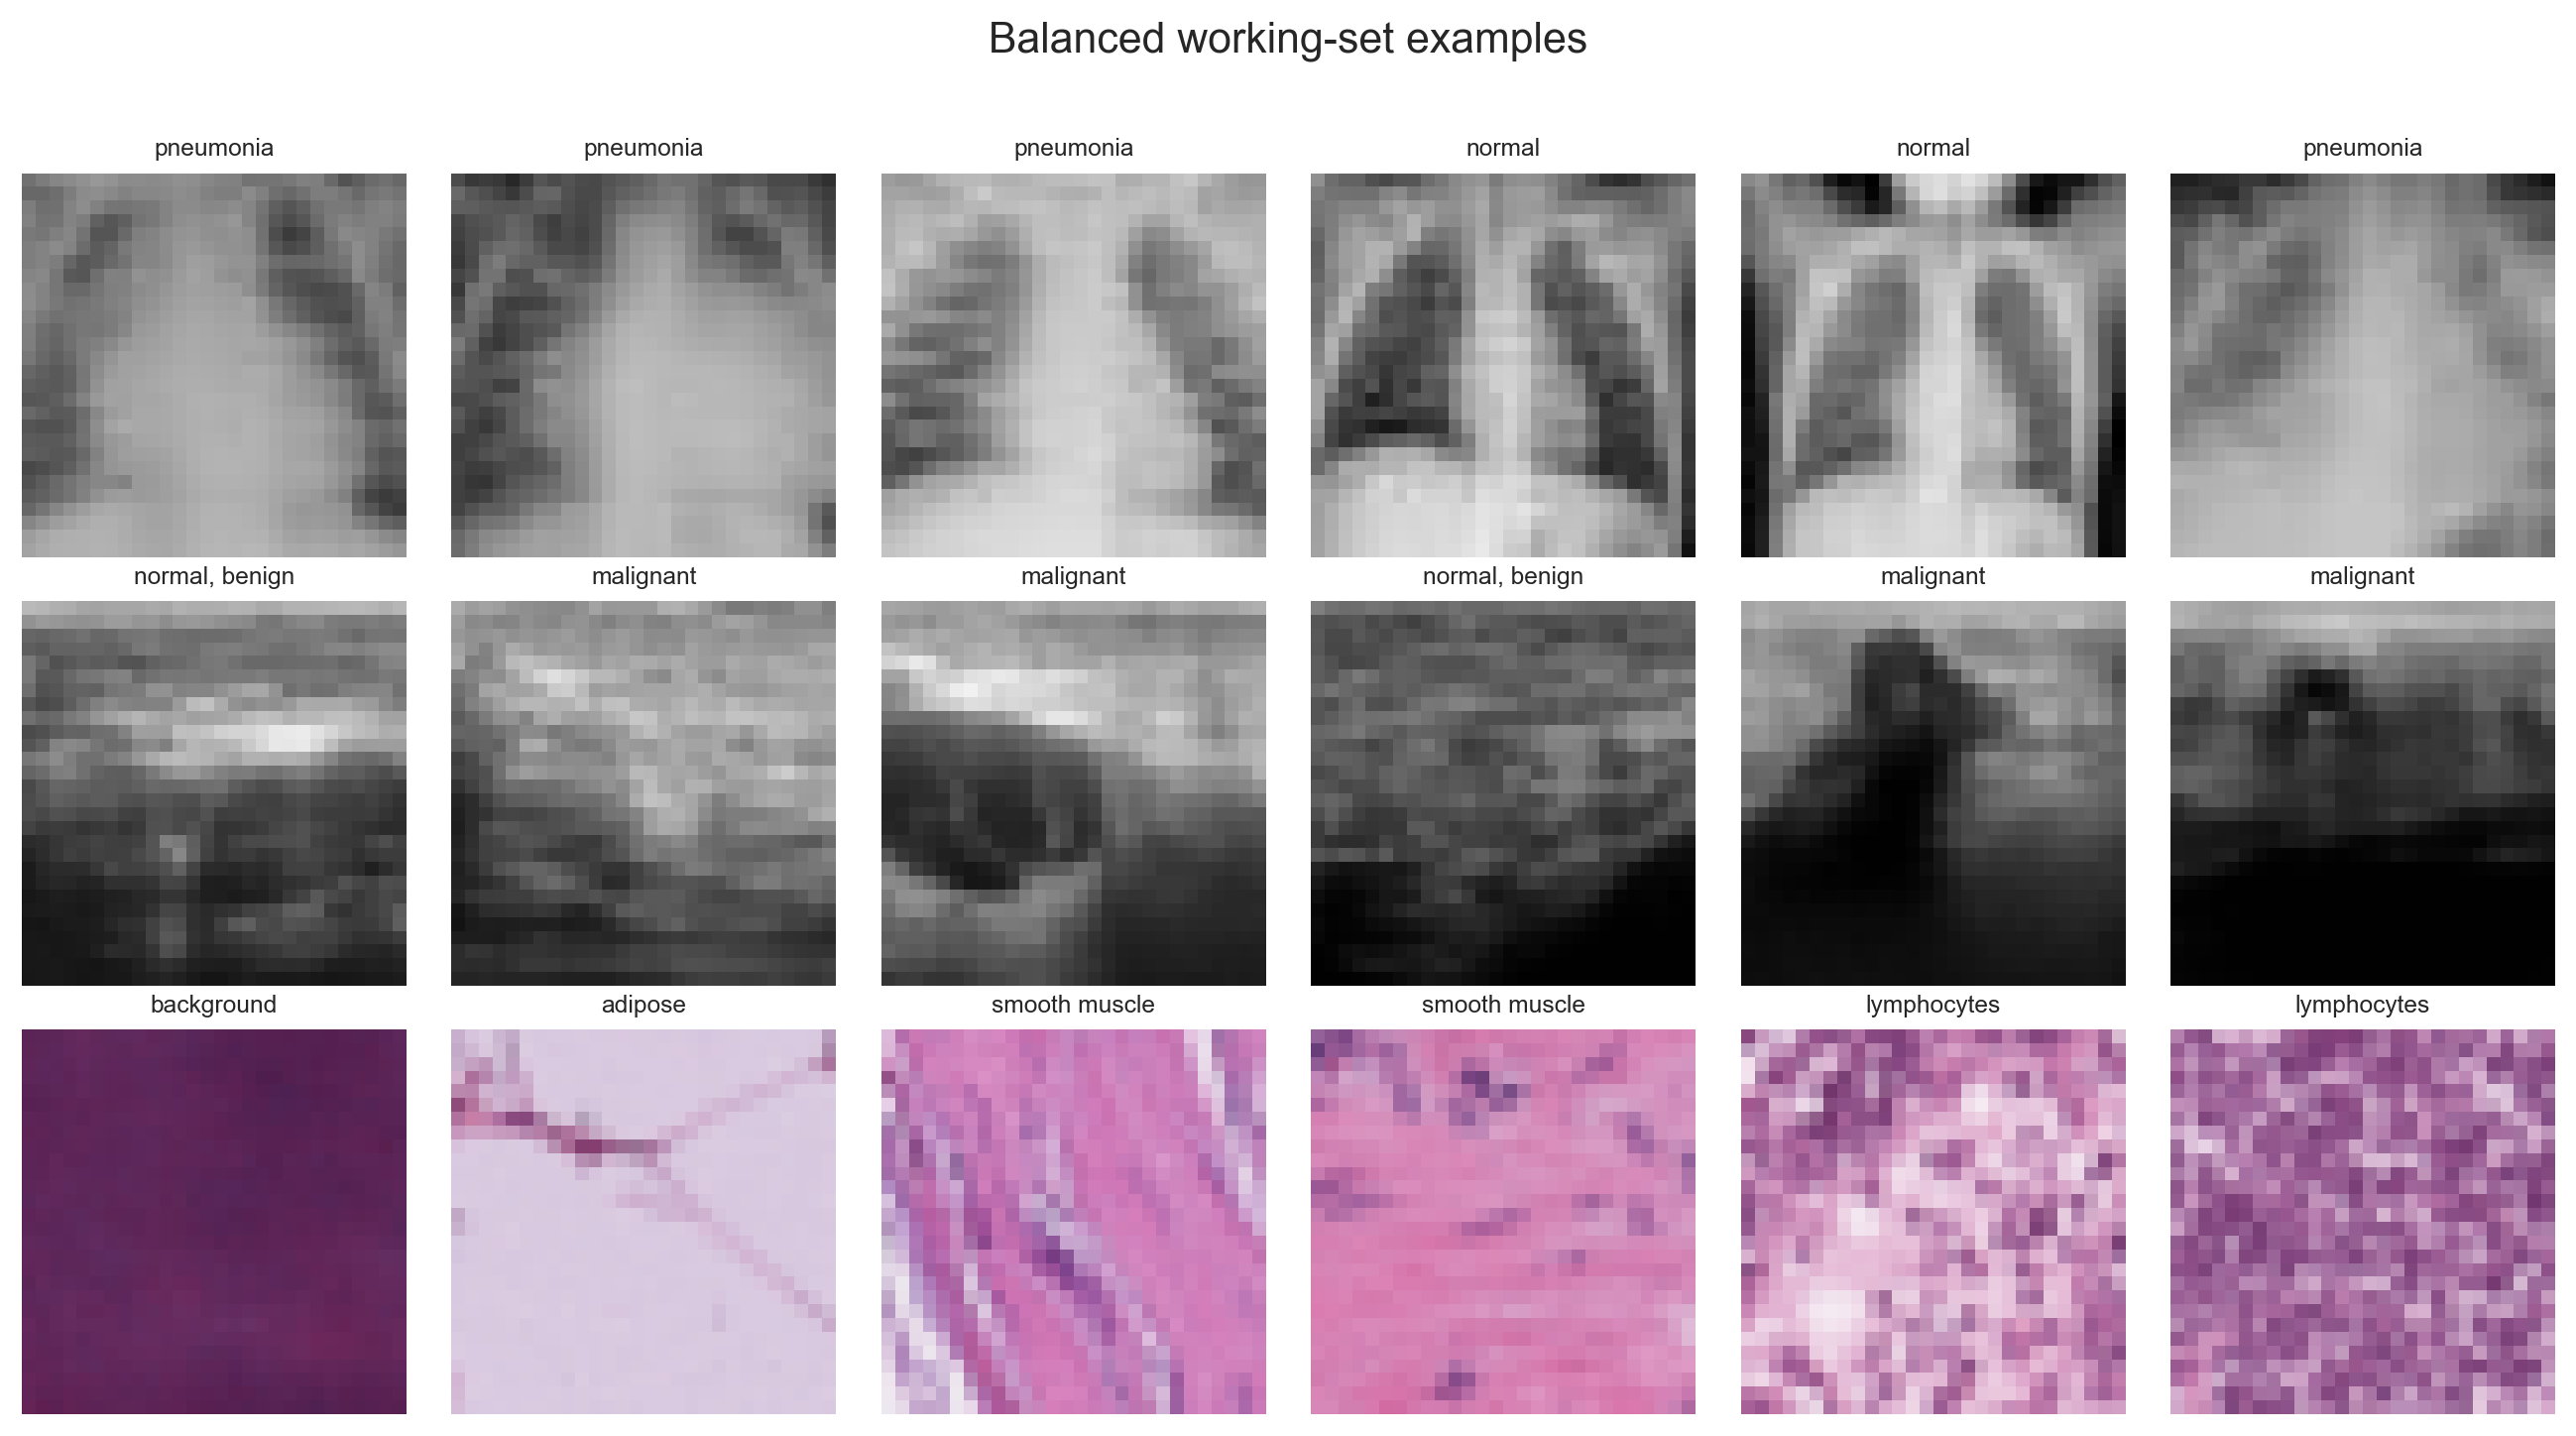

PosixPath('/Users/summermalik/Desktop/medical-msint/output/figures/dataset_examples.png')

In [4]:
fig, axes = plt.subplots(len(DATASET_NAMES), 6, figsize=(12, 6.5))
for row, dataset_name in enumerate(DATASET_NAMES):
    data = dataset_cache[dataset_name]
    label_map = data["info"].get("label", {})
    for col in range(6):
        image = data["X_train"][col]
        ax = axes[row, col]
        if image.shape[-1] == 1:
            ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(image)
        label = label_map.get(str(data["y_train"][col]), str(data["y_train"][col]))
        ax.set_title(label, fontsize=8)
        ax.axis("off")
    axes[row, 0].set_ylabel(dataset_name, fontsize=10)
fig.suptitle("Balanced working-set examples", y=1.01, fontsize=14)
fig.tight_layout()
save_figure("dataset_examples.png", fig)

## Experimental design

1. Train a full-feature logistic-regression reference model on flattened 28×28 images.
2. Fit PCA on training images only and evaluate 4, 8, 16, 32, and 64 components.
3. Fit logistic regression, random forest, small MLP, dummy classifier, and linear SVM on each compressed representation.
4. Compare full-feature and compressed logistic-regression responses to identical image perturbations.
5. Repeat the representation audit across all datasets.
6. On PneumoniaMNIST, compare a simulated 4-qubit VQC with matched classical models using exactly the same four PCA features and examples.
7. Quantify reliability with 50 label shuffles and bootstrap confidence intervals.

This design is an audit, not a clinical validation study. The full-feature logistic model is a reference response function—not an oracle and not a ground-truth explanation model.

## Diagnostic image perturbation probes

The probes are controlled representation diagnostics. They are **not clinical ground truth** and they do not assert that a particular region or texture is medically causal.

- **Center occlusion:** removes a central patch.
- **Texture weakening:** average-pools and upsamples the image.
- **Boundary weakening:** applies local cross-neighborhood smoothing.
- **Contrast attenuation:** contracts intensities toward the per-image mean.
- **Gaussian-like noise:** adds deterministic, low-amplitude pixel noise.
- **Off-center occlusion:** removes a fixed patch away from the center as a location control.
- **Patch sweep:** moves an occlusion patch across the image to form sensitivity maps.

In [5]:
def patch_occlusion(images, top, left, patch_size=7):
    output = images_to_float(images).copy()
    output[:, top:top + patch_size, left:left + patch_size, :] = 0.0
    return output


def center_occlusion(images, patch_size=8):
    images = images_to_float(images)
    height, width = images.shape[1:3]
    return patch_occlusion(
        images, height // 2 - patch_size // 2, width // 2 - patch_size // 2, patch_size
    )


def off_center_occlusion(images, patch_size=8):
    images = images_to_float(images)
    height, width = images.shape[1:3]
    return patch_occlusion(images, height // 4, width // 4, patch_size)


def texture_weakening(images, factor=2):
    images = images_to_float(images)
    n, height, width, channels = images.shape
    small = images.reshape(
        n, height // factor, factor, width // factor, factor, channels
    ).mean(axis=(2, 4))
    return np.repeat(np.repeat(small, factor, axis=1), factor, axis=2)


def boundary_weakening(images):
    images = images_to_float(images)
    padded = np.pad(images, ((0, 0), (1, 1), (1, 1), (0, 0)), mode="edge")
    return (
        padded[:, 1:-1, 1:-1] + padded[:, :-2, 1:-1] + padded[:, 2:, 1:-1]
        + padded[:, 1:-1, :-2] + padded[:, 1:-1, 2:]
    ) / 5.0


def contrast_attenuation(images, strength=0.45):
    images = images_to_float(images)
    means = images.mean(axis=(1, 2), keepdims=True)
    return np.clip(means + strength * (images - means), 0.0, 1.0)


def gaussian_like_noise(images, sigma=0.08, seed=SEED):
    images = images_to_float(images)
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, sigma, size=images.shape).astype(np.float32)
    return np.clip(images + noise, 0.0, 1.0)


def make_probe_sets(images, seed=SEED):
    return {
        "center_occlusion": center_occlusion(images),
        "texture_weakening": texture_weakening(images),
        "boundary_weakening": boundary_weakening(images),
        "contrast_attenuation": contrast_attenuation(images),
        "gaussian_like_noise": gaussian_like_noise(images, seed=seed),
        "off_center_occlusion": off_center_occlusion(images),
    }


for offset, data in enumerate(dataset_cache.values()):
    data["probe_images"] = make_probe_sets(data["X_test"], seed=SEED + offset)
    data["probe_flat_sets"] = {
        name: flatten_images(images) for name, images in data["probe_images"].items()
    }

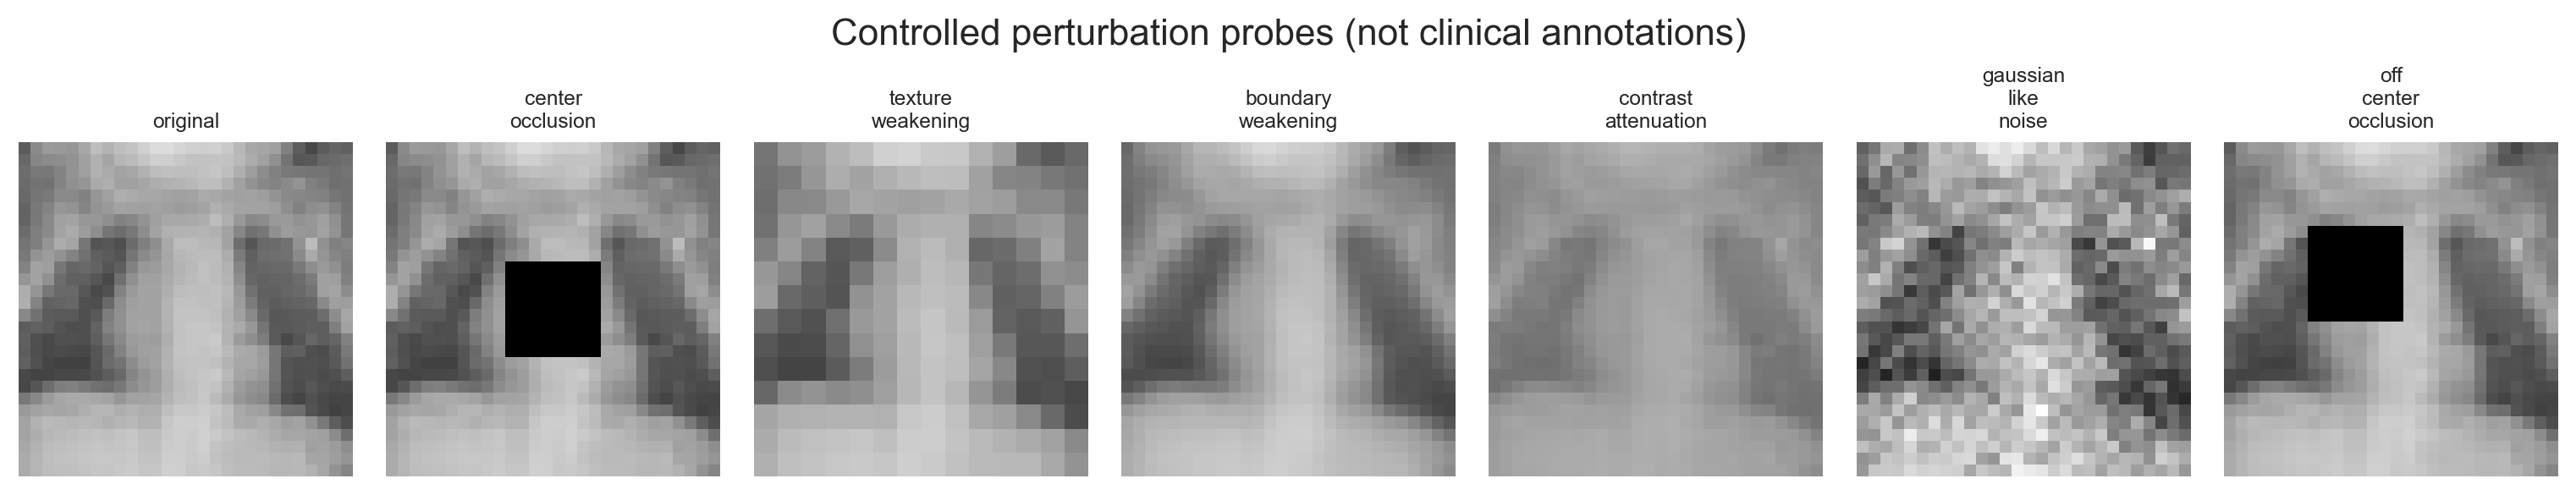

PosixPath('/Users/summermalik/Desktop/medical-msint/output/figures/perturbation_probe_examples.png')

In [6]:
example_data = dataset_cache[QUANTUM_DATASET_NAME]
original = example_data["X_test"][0]
probe_names = list(example_data["probe_images"])
fig, axes = plt.subplots(1, 1 + len(probe_names), figsize=(14, 2.6))
panels = [("original", original)] + [
    (name, example_data["probe_images"][name][0]) for name in probe_names
]
for ax, (name, image) in zip(axes, panels):
    ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(name.replace("_", "\n"), fontsize=8)
    ax.axis("off")
fig.suptitle("Controlled perturbation probes (not clinical annotations)", y=1.02)
fig.tight_layout()
save_figure("perturbation_probe_examples.png", fig)

## Metrics and preservation definitions

Predictive metrics are accuracy, balanced accuracy, macro F1, and AUC (binary or macro one-vs-rest when defined). Probe response uses:

- **Probability shift** \(s\): mean absolute positive-class change for binary tasks, or mean total-variation distance for multiclass tasks.
- **Flip rate**: fraction of examples whose predicted class changes.
- **Response ratio**: \(s_{candidate}/(s_{reference}+\epsilon)\). Below 1 means dampened sensitivity; above 1 means amplified sensitivity.
- **Response distortion**: \(|s_{candidate}-s_{reference}|\).
- **Diagnostic information preservation score**:

$$P = 1 - \frac{|s_{candidate}-s_{reference}|}{|s_{candidate}|+|s_{reference}|+\epsilon}.$$

The score lies near 1 when response magnitudes match and near 0 when sensitivity is lost or strongly distorted. It measures agreement with the chosen reference model—not preservation of clinical truth. Probe results should always be interpreted beside the reference shift because a preserved non-response is not evidence that a probe is diagnostically meaningful.

In [7]:
def probability_matrix(model, features):
    probabilities = np.asarray(model.predict_proba(features))
    return probabilities if probabilities.ndim == 2 else probabilities[:, None]


def safe_auc(y_true, probabilities):
    try:
        classes = np.unique(y_true)
        if len(classes) == 2:
            return float(roc_auc_score(y_true, probabilities[:, 1]))
        return float(roc_auc_score(y_true, probabilities, multi_class="ovr", average="macro"))
    except (ValueError, IndexError):
        return np.nan


def metric_bundle(y_true, predictions, probabilities):
    return {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predictions)),
        "macro_f1": float(f1_score(y_true, predictions, average="macro")),
        "auc": safe_auc(y_true, probabilities),
    }


def probability_shift(original_probabilities, perturbed_probabilities):
    if original_probabilities.shape[1] == 2:
        return float(np.mean(np.abs(original_probabilities[:, 1] - perturbed_probabilities[:, 1])))
    return float(np.mean(np.sum(np.abs(original_probabilities - perturbed_probabilities), axis=1) / 2.0))


def flip_rate(original_predictions, perturbed_predictions):
    return float(np.mean(np.asarray(original_predictions) != np.asarray(perturbed_predictions)))


def preservation_score(reference_shift, candidate_shift, eps=1e-8):
    return float(np.clip(
        1.0 - abs(candidate_shift - reference_shift)
        / (abs(candidate_shift) + abs(reference_shift) + eps),
        0.0,
        1.0,
    ))


def response_ratio(reference_shift, candidate_shift, eps=1e-8):
    return float(candidate_shift / (reference_shift + eps))


def make_compressed_model(model_name, seed=SEED):
    if model_name == "logistic_regression":
        estimator = LogisticRegression(max_iter=700, class_weight="balanced", random_state=seed)
        return Pipeline([("scale", StandardScaler()), ("model", estimator)])
    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=120, min_samples_leaf=2, class_weight="balanced", n_jobs=-1,
            random_state=seed,
        )
    if model_name == "small_mlp":
        estimator = MLPClassifier(
            hidden_layer_sizes=(16,), max_iter=250, early_stopping=True,
            validation_fraction=0.15, random_state=seed,
        )
        return Pipeline([("scale", StandardScaler()), ("model", estimator)])
    if model_name == "dummy":
        return DummyClassifier(strategy="prior", random_state=seed)
    if model_name == "linear_svm":
        estimator = SVC(
            kernel="linear", probability=True, class_weight="balanced", random_state=seed
        )
        return Pipeline([("scale", StandardScaler()), ("model", estimator)])
    raise ValueError(f"Unknown model: {model_name}")

## PCA compression and variance retention

PCA is fit only on each training subset. The reported retained variance is descriptive, not a guarantee that class-relevant or clinically meaningful structure survives. A single 64-component PCA fit per dataset is sliced to obtain nested lower-dimensional representations, making component comparisons internally consistent.

## Classical compressed baselines

The five compressed baselines separate representation quality from the inductive bias of any one classifier. Preservation scores use compressed logistic regression because the full-feature reference is also logistic regression; the remaining models test whether predictive conclusions are model-specific.

In [8]:
classical_rows = []
variance_rows = []
preservation_rows = []
reference_rows = []
model_names = ["logistic_regression", "random_forest", "small_mlp", "dummy", "linear_svm"]

audit_start = time.time()

for dataset_name, data in dataset_cache.items():
    print(f"Auditing {dataset_name} ...")
    x_train, x_test = data["X_train_flat"], data["X_test_flat"]
    y_train, y_test = data["y_train"], data["y_test"]

    # Full-feature logistic response reference. One-vs-rest liblinear
    # keeps the multiclass PathMNIST audit stable and laptop-scale.
    reference_model = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            solver="liblinear", max_iter=250,
            class_weight="balanced", random_state=SEED,
        )),
    ])
    reference_model.fit(x_train, y_train)
    reference_probabilities = probability_matrix(reference_model, x_test)
    reference_predictions = reference_model.predict(x_test)
    reference_metrics = metric_bundle(y_test, reference_predictions, reference_probabilities)
    reference_rows.append({"dataset": dataset_name, "model": "full_feature_logistic", **reference_metrics})

    reference_probe_responses = {}
    for probe_name, probe_flat in data["probe_flat_sets"].items():
        probe_probabilities = probability_matrix(reference_model, probe_flat)
        probe_predictions = reference_model.predict(probe_flat)
        reference_probe_responses[probe_name] = {
            "shift": probability_shift(reference_probabilities, probe_probabilities),
            "flip": flip_rate(reference_predictions, probe_predictions),
        }

    max_components = min(max(COMPRESSION_LEVELS), len(x_train) - 1, x_train.shape[1])
    pca = PCA(n_components=max_components, svd_solver="randomized", random_state=SEED)
    x_train_pca_all = pca.fit_transform(x_train)
    x_test_pca_all = pca.transform(x_test)

    data["reference_model"] = reference_model
    data["reference_metrics"] = reference_metrics
    data["reference_probe_responses"] = reference_probe_responses
    data["pca"] = pca
    data["compressed_logistic_models"] = {}

    for components in COMPRESSION_LEVELS:
        if components > max_components:
            continue
        x_train_pca = x_train_pca_all[:, :components]
        x_test_pca = x_test_pca_all[:, :components]
        retained = float(pca.explained_variance_ratio_[:components].sum())
        variance_rows.append({
            "dataset": dataset_name,
            "components": components,
            "variance_retained": retained,
        })

        for model_name in model_names:
            model = make_compressed_model(model_name)
            model.fit(x_train_pca, y_train)
            predictions = model.predict(x_test_pca)
            probabilities = probability_matrix(model, x_test_pca)
            classical_rows.append({
                "dataset": dataset_name,
                "components": components,
                "model": model_name,
                "variance_retained": retained,
                **metric_bundle(y_test, predictions, probabilities),
            })
            if model_name == "logistic_regression":
                data["compressed_logistic_models"][components] = model
                for probe_name, probe_flat in data["probe_flat_sets"].items():
                    probe_pca = pca.transform(probe_flat)[:, :components]
                    probe_probabilities = probability_matrix(model, probe_pca)
                    probe_predictions = model.predict(probe_pca)
                    candidate_shift = probability_shift(probabilities, probe_probabilities)
                    candidate_flip = flip_rate(predictions, probe_predictions)
                    reference_shift = reference_probe_responses[probe_name]["shift"]
                    reference_flip = reference_probe_responses[probe_name]["flip"]
                    preservation_rows.append({
                        "dataset": dataset_name,
                        "components": components,
                        "probe": probe_name,
                        "variance_retained": retained,
                        "reference_probability_shift": reference_shift,
                        "compressed_probability_shift": candidate_shift,
                        "reference_flip_rate": reference_flip,
                        "compressed_flip_rate": candidate_flip,
                        "response_ratio": response_ratio(reference_shift, candidate_shift),
                        "response_distortion": abs(candidate_shift - reference_shift),
                        "diagnostic_information_preservation_score": preservation_score(
                            reference_shift, candidate_shift
                        ),
                    })

classical_df = pd.DataFrame(classical_rows)
variance_df = pd.DataFrame(variance_rows)
preservation_df = pd.DataFrame(preservation_rows)
reference_df = pd.DataFrame(reference_rows)

save_table(classical_df, "classical_compression_results.csv")
save_table(variance_df, "variance_retention_results.csv")
save_table(preservation_df, "preservation_results.csv")
save_table(reference_df, "full_feature_reference_results.csv")

print(f"Classical and preservation audit completed in {time.time() - audit_start:.1f} seconds")
display(classical_df.head())
display(preservation_df.head())

Auditing pneumoniamnist ...


Auditing breastmnist ...


Auditing pathmnist ...


Classical and preservation audit completed in 10.3 seconds


,dataset,components,model,variance_retained,accuracy,balanced_accuracy,macro_f1,auc
0,pneumoniamnist,4,logistic_regression,0.58219,0.844444,0.844444,0.844308,0.922853
1,pneumoniamnist,4,random_forest,0.58219,0.837037,0.837037,0.836714,0.920027
2,pneumoniamnist,4,small_mlp,0.58219,0.800000,0.800000,0.799461,0.887078
3,pneumoniamnist,4,dummy,0.58219,0.500000,0.500000,0.333333,0.500000
4,pneumoniamnist,4,linear_svm,0.58219,0.840741,0.840741,0.840634,0.920165


,dataset,components,probe,variance_retained,reference_probability_shift,compressed_probability_shift,reference_flip_rate,compressed_flip_rate,response_ratio,response_distortion,diagnostic_information_preservation_score
0,pneumoniamnist,4,center_occlusion,0.58219,0.154924,0.013048,0.144444,0.000000,0.084224,0.141876,0.155363
1,pneumoniamnist,4,texture_weakening,0.58219,0.057720,0.024465,0.062963,0.007407,0.423849,0.033256,0.595357
2,pneumoniamnist,4,boundary_weakening,0.58219,0.032901,0.019093,0.029630,0.007407,0.580318,0.013808,0.734432
3,pneumoniamnist,4,contrast_attenuation,0.58219,0.260900,0.320603,0.281481,0.418519,1.228835,0.059703,0.897330
4,pneumoniamnist,4,gaussian_like_noise,0.58219,0.089224,0.015742,0.096296,0.000000,0.176433,0.073482,0.299945


## Multi-dataset representation audit

These figures should be read together. Performance can remain stable while probe response changes, and high explained variance can coexist with weak response preservation. Neither finding alone establishes that a probe is clinically important.

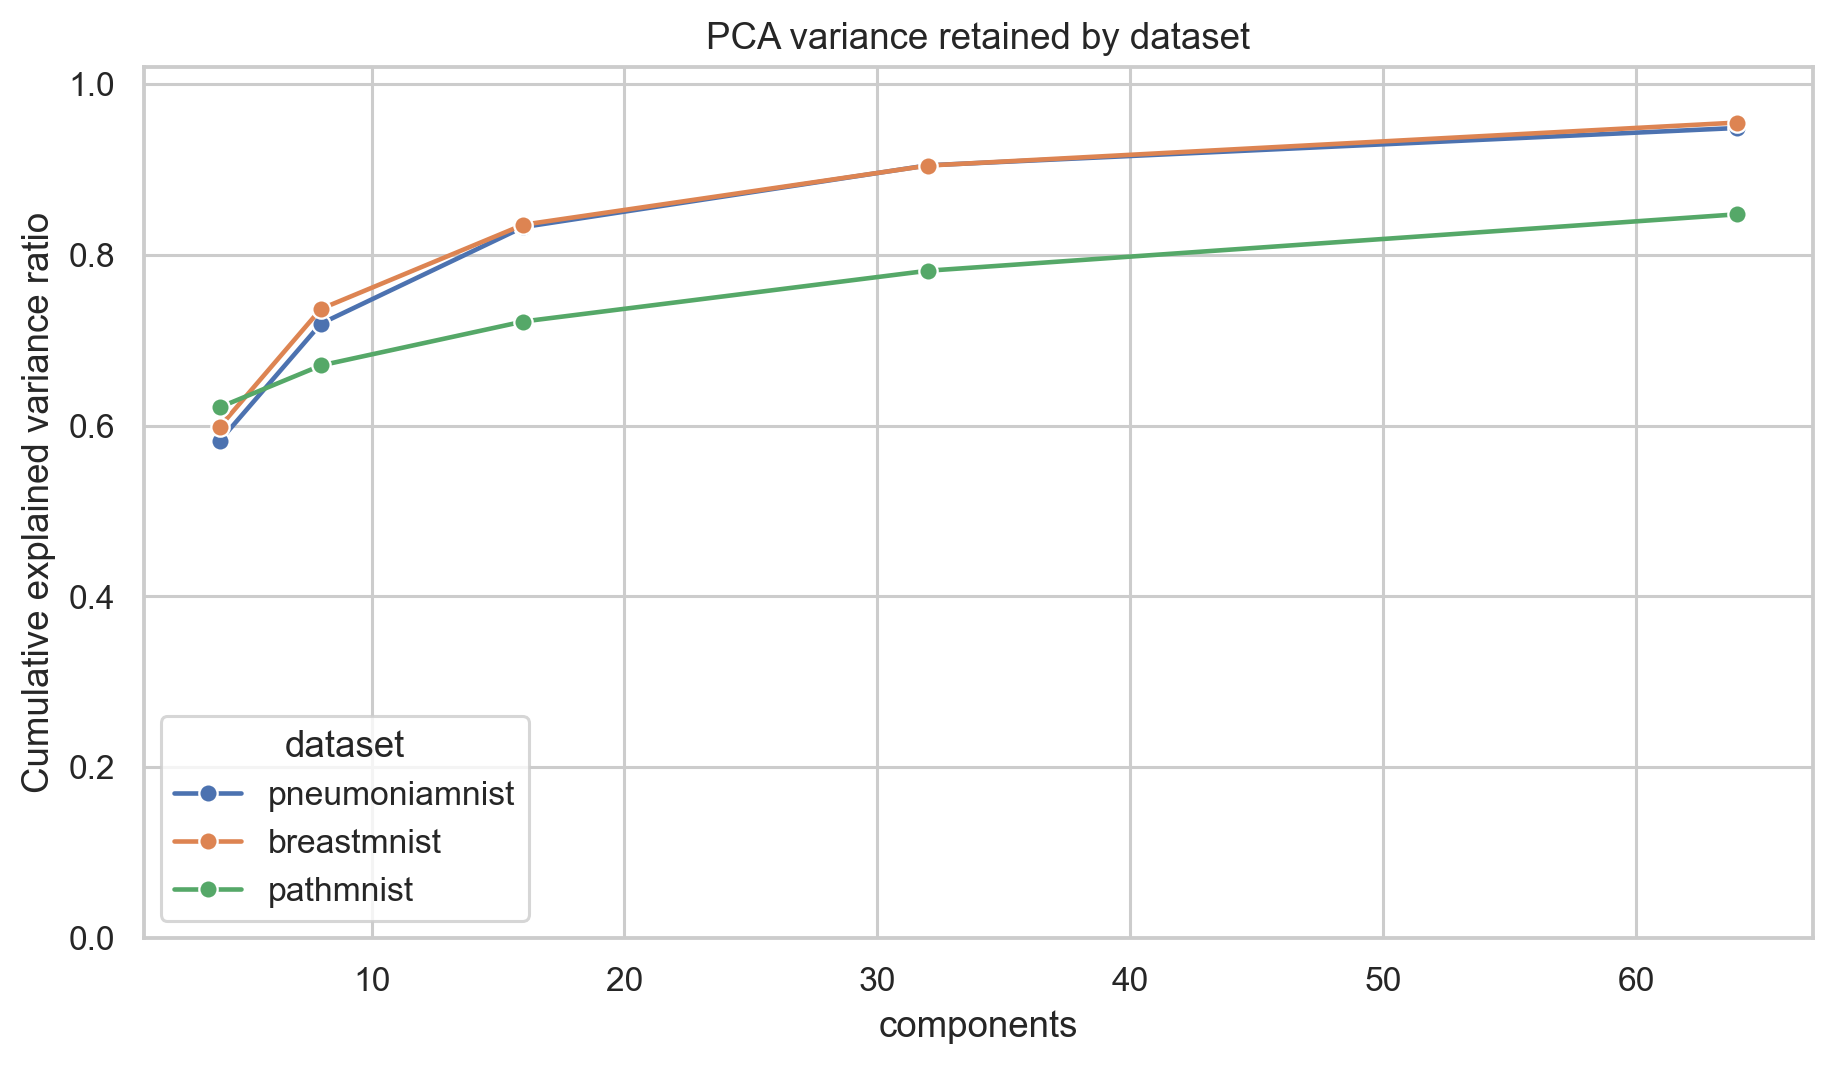

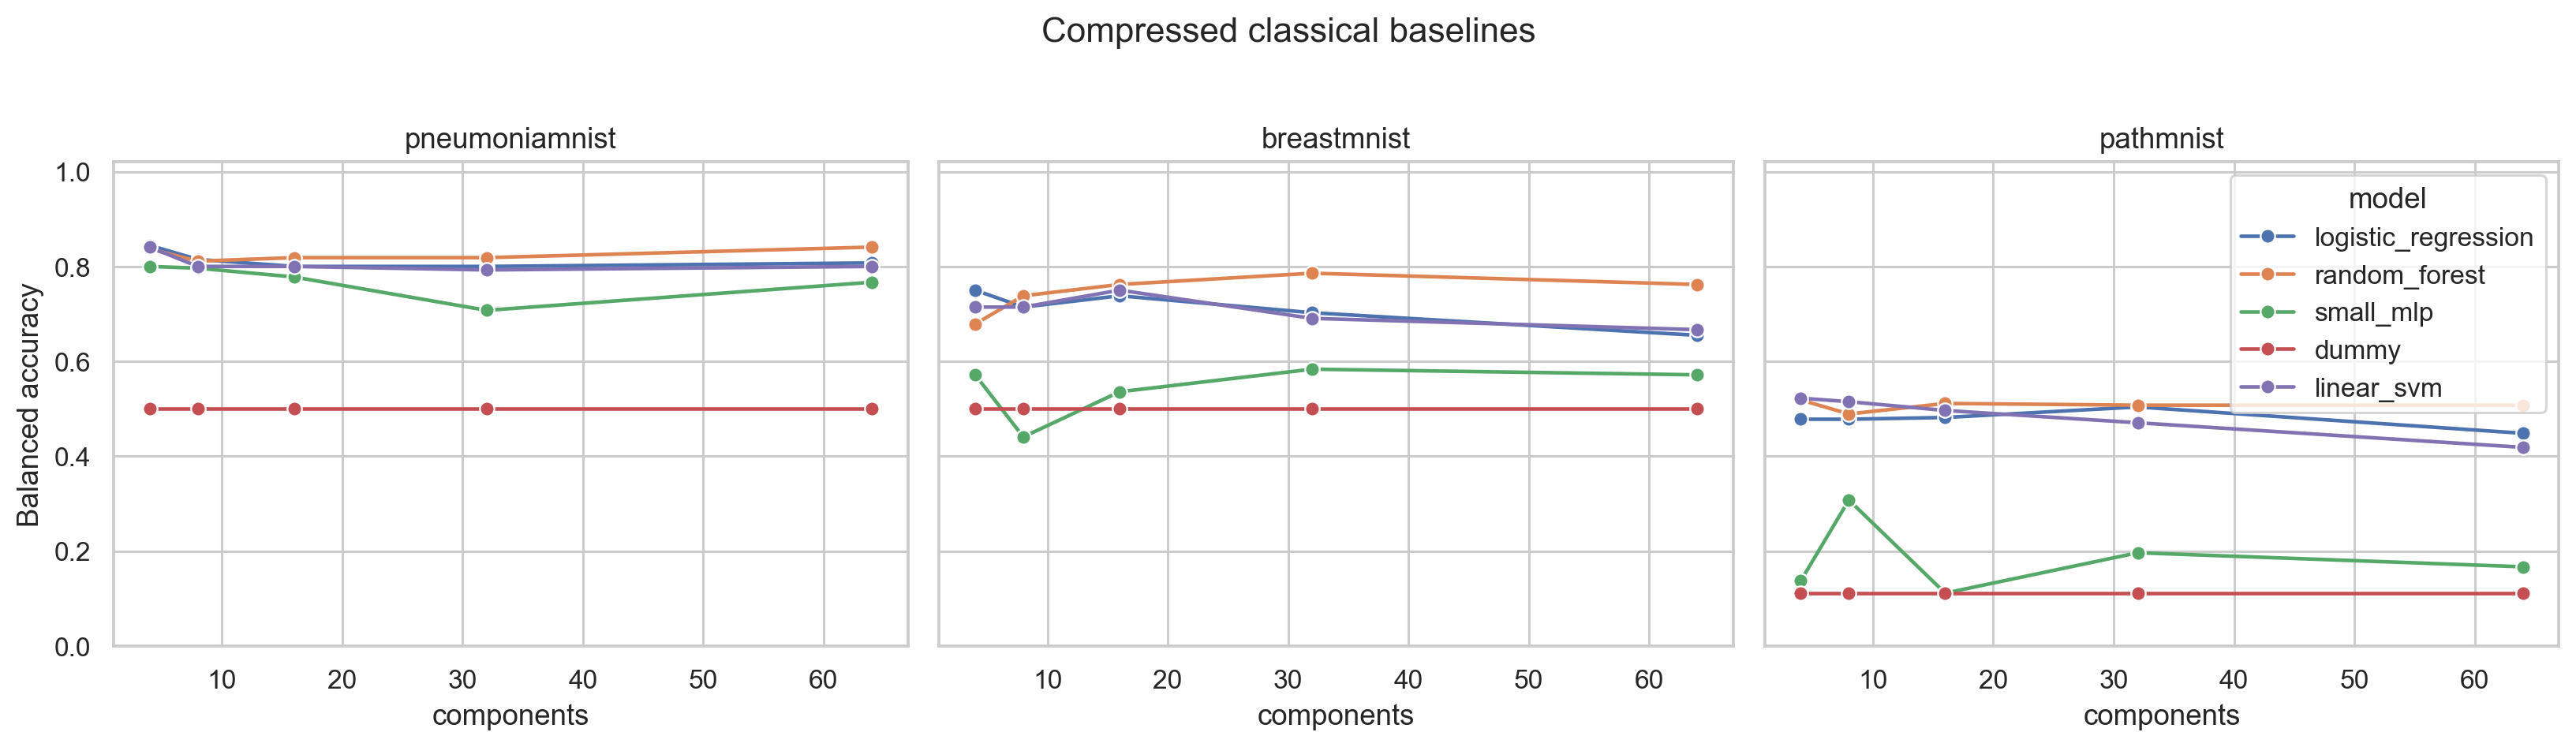

PosixPath('/Users/summermalik/Desktop/medical-msint/output/figures/compression_accuracy_by_dataset.png')

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(
    data=variance_df, x="components", y="variance_retained", hue="dataset",
    marker="o", ax=ax,
)
ax.set_ylim(0, 1.02)
ax.set_title("PCA variance retained by dataset")
ax.set_ylabel("Cumulative explained variance ratio")
fig.tight_layout()
save_figure("pca_variance_retention_by_dataset.png", fig)

fig, axes = plt.subplots(1, len(DATASET_NAMES), figsize=(15, 4.2), sharey=True)
for ax, dataset_name in zip(axes, DATASET_NAMES):
    subset = classical_df[classical_df["dataset"] == dataset_name]
    sns.lineplot(
        data=subset, x="components", y="balanced_accuracy", hue="model",
        marker="o", ax=ax, legend=(dataset_name == DATASET_NAMES[-1]),
    )
    ax.set_title(dataset_name)
    ax.set_ylim(0, 1.02)
    if dataset_name != DATASET_NAMES[-1] and ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].set_ylabel("Balanced accuracy")
fig.suptitle("Compressed classical baselines", y=1.02)
fig.tight_layout()
save_figure("compression_accuracy_by_dataset.png", fig)

## Diagnostic information preservation score

The heatmap is the central representation-audit result. A value near 1 means the compressed logistic model has a probability-response magnitude similar to the full-feature logistic reference for that probe. A low score flags representation-dependent distortion for further investigation; it is not a clinical failure label.

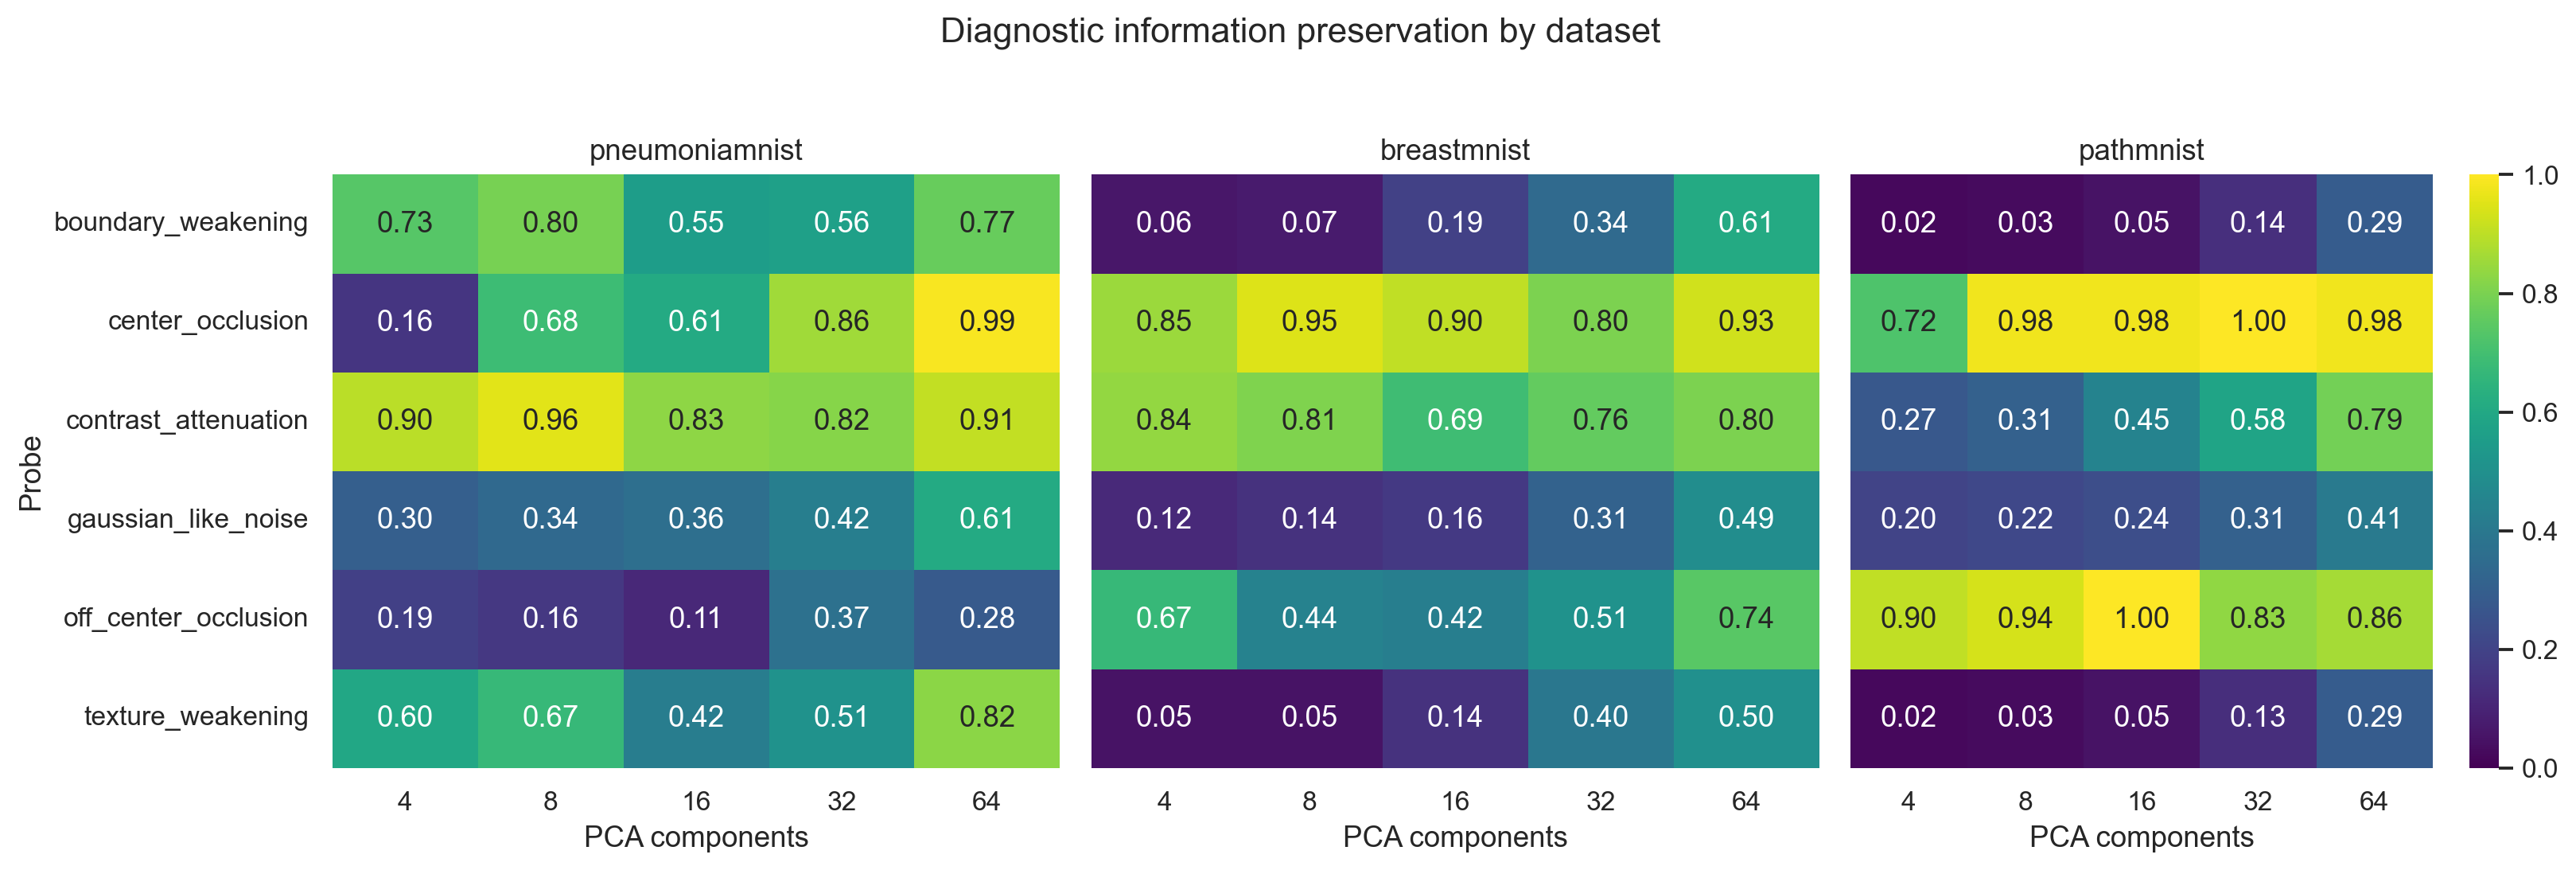

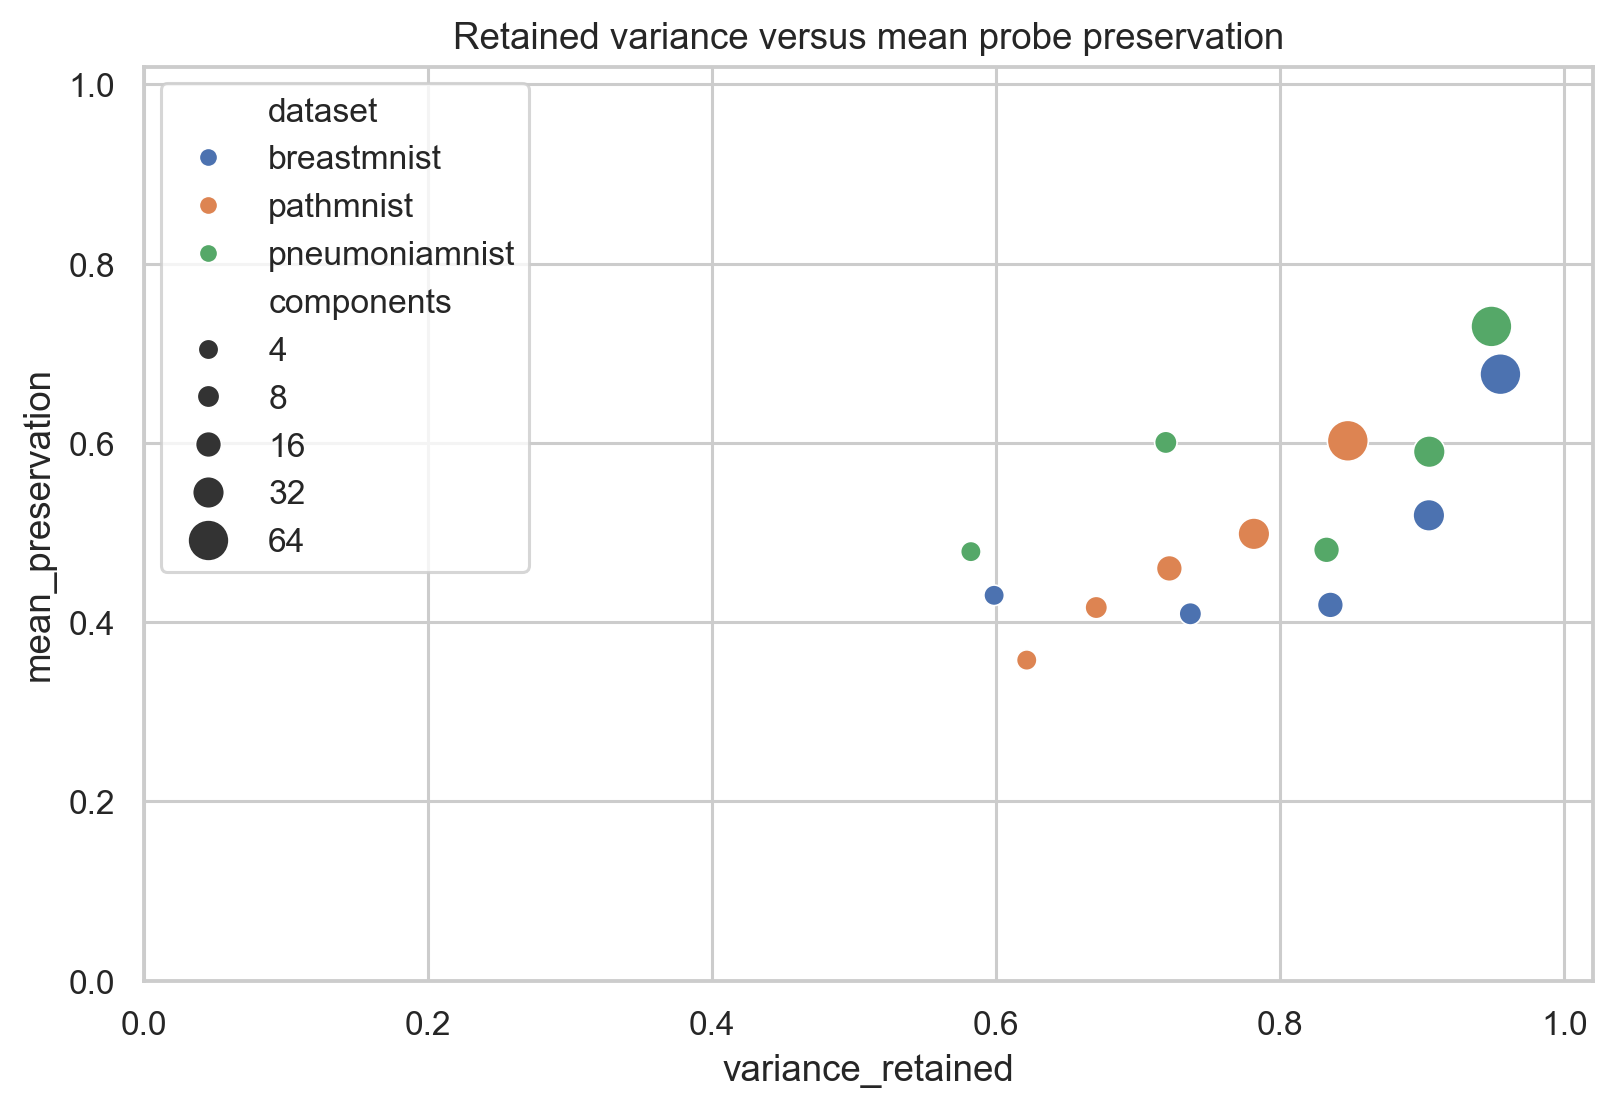

PosixPath('/Users/summermalik/Desktop/medical-msint/output/figures/variance_vs_preservation_scatter.png')

In [10]:
fig, axes = plt.subplots(1, len(DATASET_NAMES), figsize=(15, 4.8), sharey=True)
for ax, dataset_name in zip(axes, DATASET_NAMES):
    matrix = (
        preservation_df[preservation_df["dataset"] == dataset_name]
        .pivot(index="probe", columns="components", values="diagnostic_information_preservation_score")
    )
    sns.heatmap(
        matrix, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f",
        cbar=(dataset_name == DATASET_NAMES[-1]), ax=ax,
    )
    ax.set_title(dataset_name)
    ax.set_xlabel("PCA components")
    ax.set_ylabel("Probe" if dataset_name == DATASET_NAMES[0] else "")
fig.suptitle("Diagnostic information preservation by dataset", y=1.03)
fig.tight_layout()
save_figure("preservation_heatmap_by_dataset.png", fig)

scatter_df = (
    preservation_df.groupby(["dataset", "components"], as_index=False)
    .agg(
        variance_retained=("variance_retained", "first"),
        mean_preservation=("diagnostic_information_preservation_score", "mean"),
    )
)
fig, ax = plt.subplots(figsize=(7.5, 5.2))
sns.scatterplot(
    data=scatter_df, x="variance_retained", y="mean_preservation",
    hue="dataset", size="components", sizes=(45, 180), ax=ax,
)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.set_title("Retained variance versus mean probe preservation")
fig.tight_layout()
save_figure("variance_vs_preservation_scatter.png", fig)

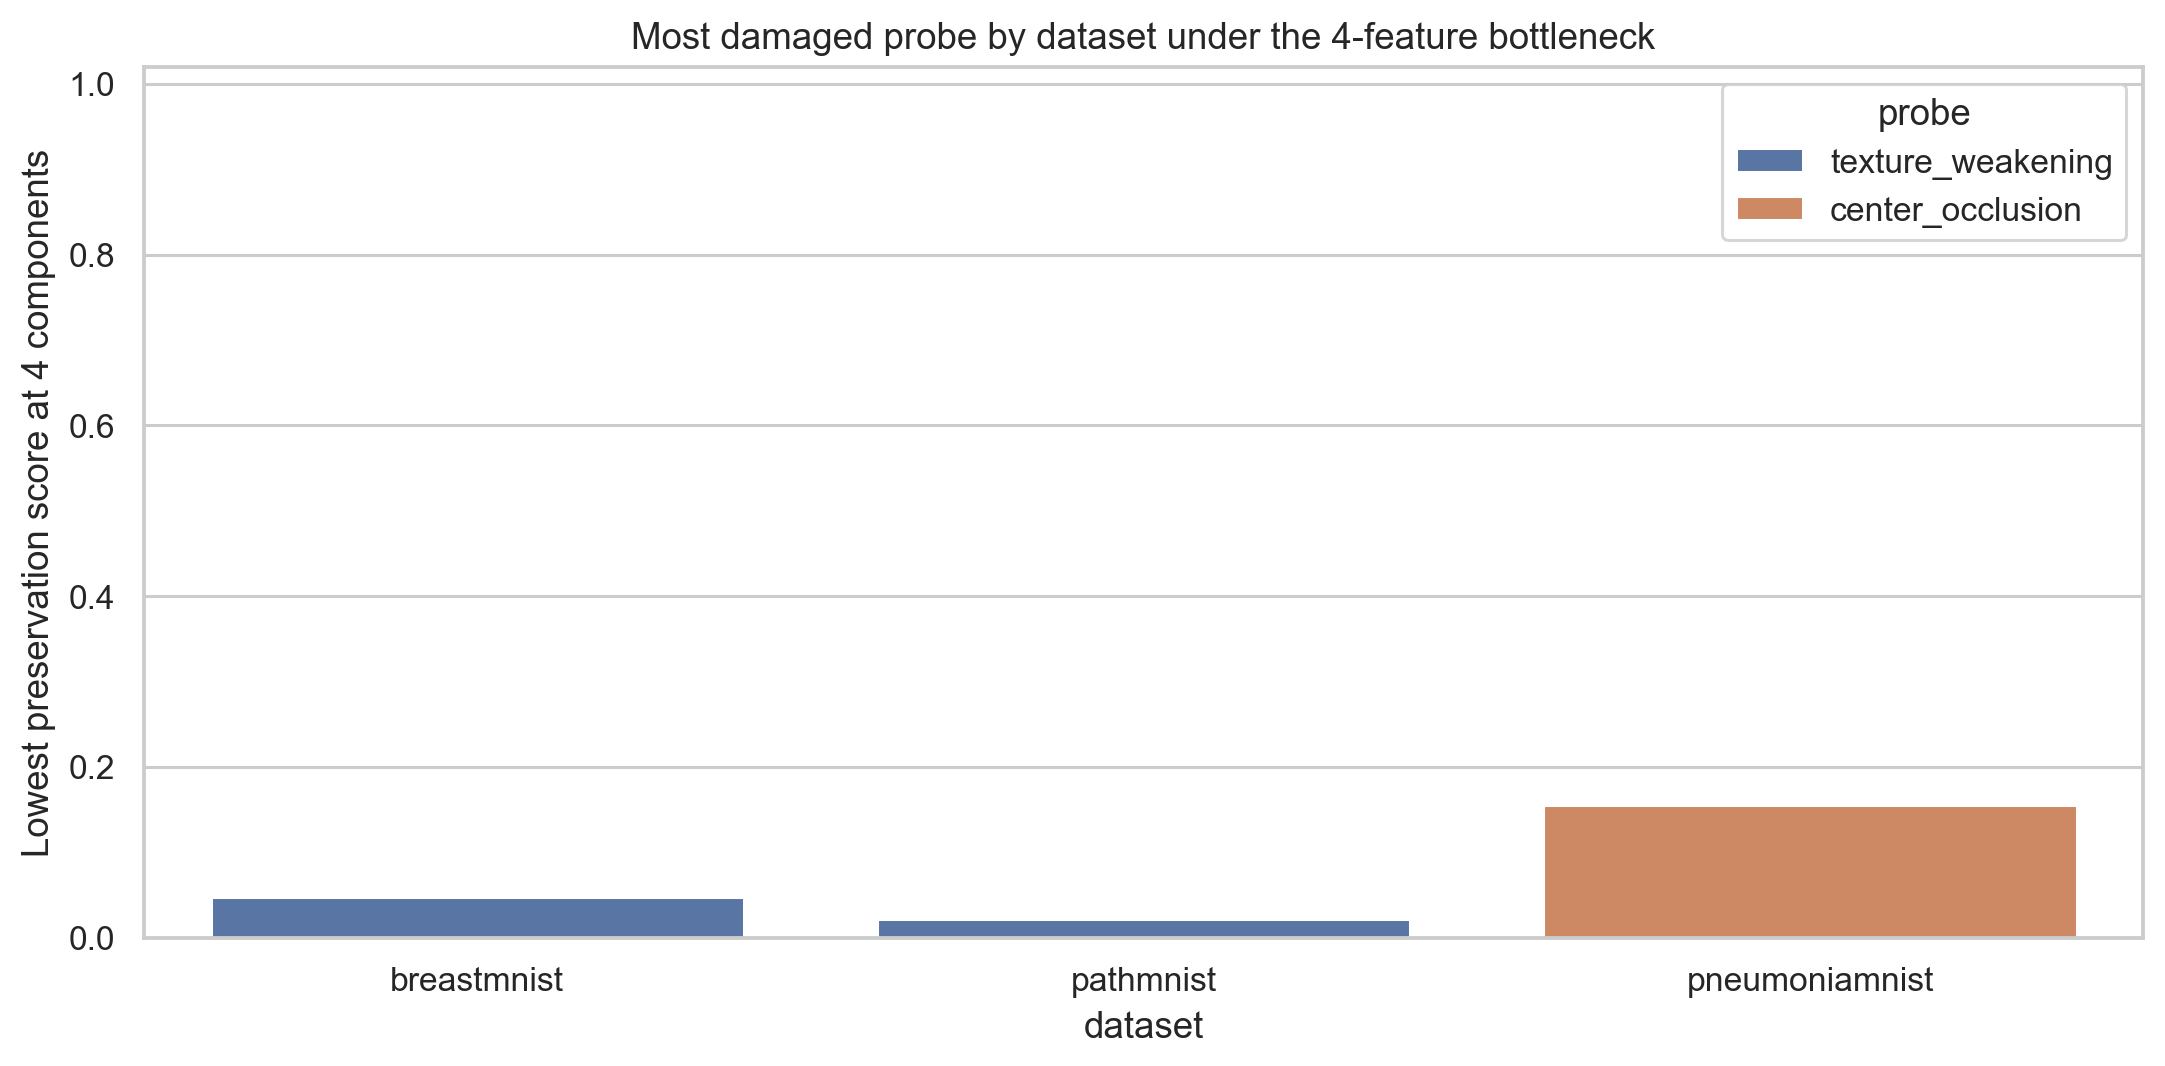

,dataset,components,model,variance_retained,accuracy,balanced_accuracy,macro_f1,auc,mean_preservation_score,mean_response_ratio,mean_response_distortion,compression_viability_score
5,breastmnist,4,logistic_regression,0.598562,0.750000,0.750000,0.749681,0.774943,0.430022,0.594699,0.095696,0.638783
6,breastmnist,8,logistic_regression,0.736713,0.714286,0.714286,0.712821,0.783447,0.409431,0.909626,0.112469,0.624706
7,breastmnist,16,logistic_regression,0.835286,0.738095,0.738095,0.737500,0.811791,0.419335,0.888577,0.120464,0.652037
8,breastmnist,32,logistic_regression,0.904631,0.702381,0.702381,0.702001,0.801020,0.519279,0.812953,0.105262,0.667580
9,breastmnist,64,logistic_regression,0.954999,0.654762,0.654762,0.653534,0.768141,0.676747,0.722080,0.068897,0.691074
10,pathmnist,4,logistic_regression,0.621520,0.477778,0.477778,0.463436,0.862577,0.357747,0.280673,0.200997,0.452557
11,pathmnist,8,logistic_regression,0.670462,0.477778,0.477778,0.464556,0.865571,0.416402,0.404601,0.165025,0.475328
12,pathmnist,16,logistic_regression,0.721932,0.481481,0.481481,0.477882,0.848441,0.460042,0.406385,0.151793,0.498195
13,pathmnist,32,logistic_regression,0.781434,0.503704,0.503704,0.492608,0.857654,0.498617,0.523073,0.163246,0.527177
14,pathmnist,64,logistic_regression,0.847561,0.448148,0.448148,0.430913,0.838858,0.602406,0.585686,0.141496,0.530058


,dataset,components,probe,variance_retained,reference_probability_shift,compressed_probability_shift,reference_flip_rate,compressed_flip_rate,response_ratio,response_distortion,diagnostic_information_preservation_score
0,breastmnist,4,texture_weakening,0.598562,0.129165,0.003113,0.119048,0.000000,0.024102,0.126052,0.047071
1,breastmnist,8,texture_weakening,0.736713,0.129165,0.003292,0.119048,0.000000,0.025488,0.125873,0.049709
2,breastmnist,16,texture_weakening,0.835286,0.129165,0.009990,0.119048,0.011905,0.077343,0.119175,0.143581
3,breastmnist,32,gaussian_like_noise,0.904631,0.185002,0.033951,0.190476,0.059524,0.183515,0.151052,0.310118
4,breastmnist,64,gaussian_like_noise,0.954999,0.185002,0.059440,0.190476,0.047619,0.321296,0.125562,0.486335
5,pathmnist,4,texture_weakening,0.621520,0.303889,0.003361,0.385185,0.018519,0.011061,0.300527,0.021880
6,pathmnist,8,boundary_weakening,0.670462,0.193915,0.002804,0.229630,0.007407,0.014459,0.191111,0.028506
7,pathmnist,16,texture_weakening,0.721932,0.303889,0.007382,0.385185,0.011111,0.024292,0.296506,0.047433
8,pathmnist,32,texture_weakening,0.781434,0.303889,0.021358,0.385185,0.070370,0.070283,0.282530,0.131335
9,pathmnist,64,texture_weakening,0.847561,0.303889,0.051089,0.385185,0.070370,0.168117,0.252800,0.287843


In [11]:
logistic_metrics = classical_df[classical_df["model"] == "logistic_regression"].copy()
mean_preservation = (
    preservation_df.groupby(["dataset", "components"], as_index=False)
    .agg(
        mean_preservation_score=("diagnostic_information_preservation_score", "mean"),
        mean_response_ratio=("response_ratio", "mean"),
        mean_response_distortion=("response_distortion", "mean"),
    )
)
viability_df = logistic_metrics.merge(mean_preservation, on=["dataset", "components"])
viability_df["compression_viability_score"] = (
    0.35 * viability_df["balanced_accuracy"]
    + 0.25 * viability_df["macro_f1"]
    + 0.30 * viability_df["mean_preservation_score"]
    + 0.10 * viability_df["variance_retained"]
)
viability_df = viability_df.sort_values(["dataset", "components"])
save_table(viability_df, "compression_viability_summary.csv")

most_damaged_df = (
    preservation_df.sort_values("diagnostic_information_preservation_score")
    .groupby(["dataset", "components"], as_index=False)
    .first()
    .sort_values(["dataset", "components"])
)
save_table(most_damaged_df, "most_damaged_probe_results.csv")

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = most_damaged_df[most_damaged_df["components"] == K_QUBITS].copy()
sns.barplot(
    data=plot_data, x="dataset", y="diagnostic_information_preservation_score",
    hue="probe", dodge=False, ax=ax,
)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Lowest preservation score at 4 components")
ax.set_title("Most damaged probe by dataset under the 4-feature bottleneck")
fig.tight_layout()
save_figure("most_damaged_probe_by_dataset.png", fig)

display(viability_df)
display(most_damaged_df)

## 4-qubit VQC prototype

The quantum experiment is intentionally downstream of the representation audit. It uses four PCA features, four qubits, angle encoding, two shallow variational layers, nearest-neighbor entanglement, and one measured expectation value.

The QNode returns **only** the quantum expectation value. A trainable classical bias is added after circuit evaluation. The model is a noiseless local simulation, not a real-device experiment and not a quantum-advantage claim.

In [12]:
qdata = dataset_cache[QUANTUM_DATASET_NAME]
assert len(np.unique(qdata["y_train"])) == 2, "The VQC prototype requires a binary dataset."

q_pca = qdata["pca"]
q_angle_scaler = StandardScaler()
q_train_raw = q_pca.transform(qdata["X_train_flat"])[:, :K_QUBITS]
q_test_raw = q_pca.transform(qdata["X_test_flat"])[:, :K_QUBITS]
q_train_all = np.clip(q_angle_scaler.fit_transform(q_train_raw), -np.pi, np.pi)
q_test_all = np.clip(q_angle_scaler.transform(q_test_raw), -np.pi, np.pi)

q_train_idx = balanced_indices(qdata["y_train"], N_TRAIN_Q, SEED + 10)
q_test_idx = balanced_indices(qdata["y_test"], N_TEST_Q, SEED + 11)
Xq_train = q_train_all[q_train_idx]
Xq_test = q_test_all[q_test_idx]
yq_train = qdata["y_train"][q_train_idx].astype(int)
yq_test = qdata["y_test"][q_test_idx].astype(int)

q_classes = np.unique(yq_train)
q_class_to_binary = {q_classes[0]: 0, q_classes[1]: 1}
yq_train_bin = np.array([q_class_to_binary[value] for value in yq_train])
yq_test_bin = np.array([q_class_to_binary[value] for value in yq_test])

def transform_to_quantum_features(flat_images):
    raw = q_pca.transform(flat_images)[:, :K_QUBITS]
    return np.clip(q_angle_scaler.transform(raw), -np.pi, np.pi)

print("Quantum train subset:", Xq_train.shape)
print("Quantum test subset:", Xq_test.shape)

Quantum train subset: (160, 4)
Quantum test subset: (120, 4)


Epoch 00 | loss=0.7645
Epoch 04 | loss=0.6497
Epoch 08 | loss=0.6102
Epoch 12 | loss=0.5796
Epoch 16 | loss=0.6062
Epoch 20 | loss=0.6315
Epoch 23 | loss=0.6215


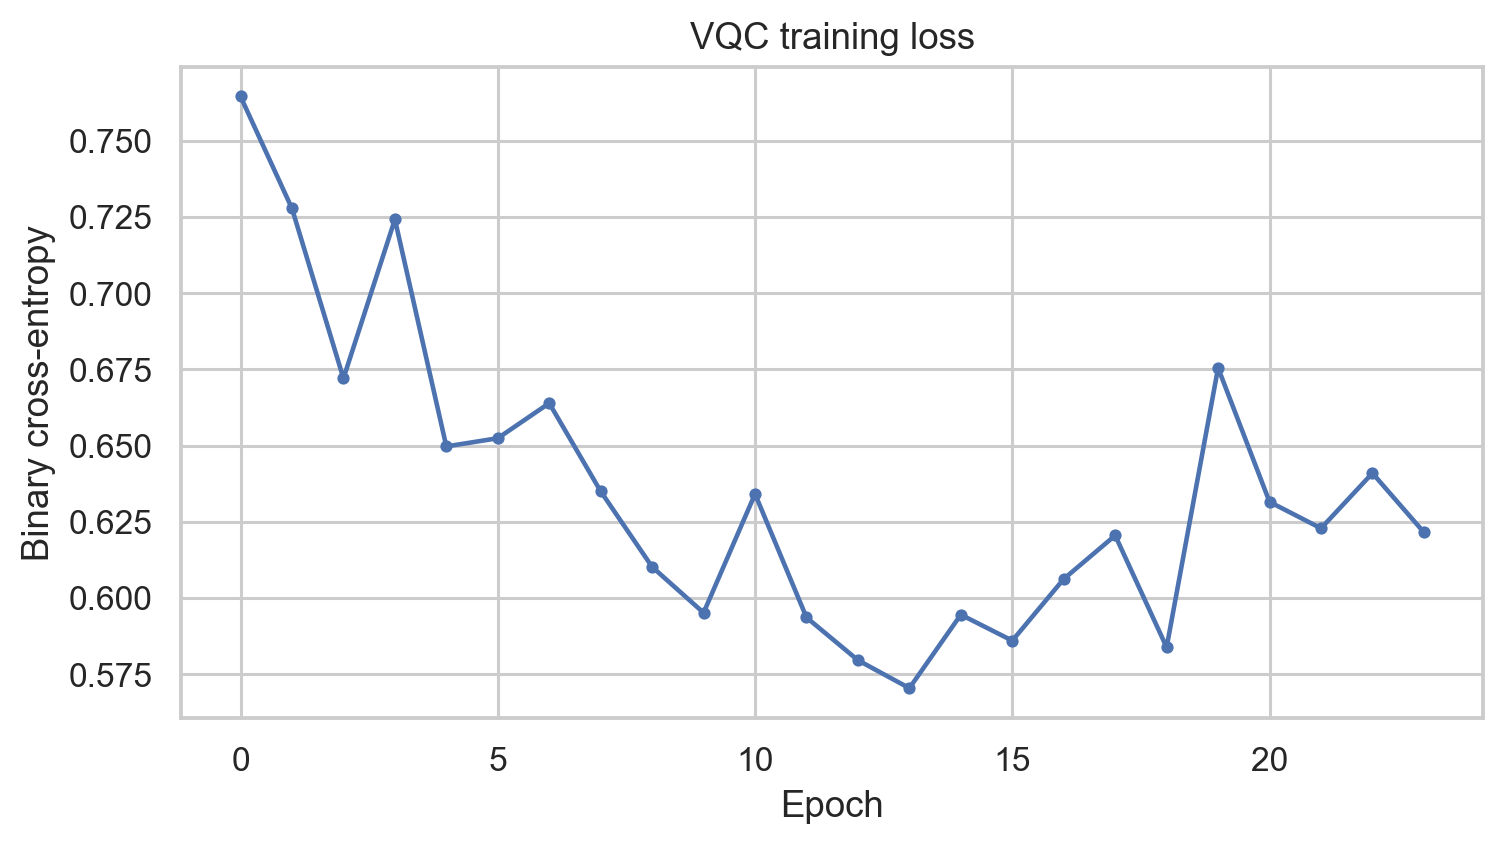

PosixPath('/Users/summermalik/Desktop/medical-msint/output/figures/vqc_training_loss.png')

In [13]:
import pennylane as qml
from pennylane import numpy as pnp

q_device = qml.device("default.qubit", wires=K_QUBITS)

@qml.qnode(q_device, interface="autograd", diff_method="backprop")
def quantum_circuit(features, weights):
    '''Return only the measured quantum expectation value.'''
    for wire in range(K_QUBITS):
        qml.RY(features[..., wire], wires=wire)
    for layer in range(N_Q_LAYERS):
        for wire in range(K_QUBITS):
            qml.RY(weights[layer, wire, 0], wires=wire)
            qml.RZ(weights[layer, wire, 1], wires=wire)
        for wire in range(K_QUBITS - 1):
            qml.CNOT(wires=[wire, wire + 1])
        qml.CNOT(wires=[K_QUBITS - 1, 0])
    return qml.expval(qml.PauliZ(0))


def unpack_vqc_parameters(parameters):
    weight_count = N_Q_LAYERS * K_QUBITS * 2
    weights = parameters[:weight_count].reshape(N_Q_LAYERS, K_QUBITS, 2)
    bias = parameters[weight_count]
    return weights, bias


def vqc_predict_proba(features, parameters):
    weights, bias = unpack_vqc_parameters(parameters)
    quantum_expectation = quantum_circuit(pnp.asarray(features), weights)
    logits = quantum_expectation + bias  # Bias is deliberately outside the QNode.
    return 1.0 / (1.0 + pnp.exp(-logits))


def binary_cross_entropy(labels, probabilities):
    labels = pnp.asarray(labels, dtype=float)
    probabilities = pnp.clip(probabilities, 1e-8, 1 - 1e-8)
    return -pnp.mean(
        labels * pnp.log(probabilities) + (1 - labels) * pnp.log(1 - probabilities)
    )


parameter_count = N_Q_LAYERS * K_QUBITS * 2 + 1
parameter_rng = np.random.default_rng(SEED)
vqc_parameters = pnp.array(
    0.05 * parameter_rng.normal(size=parameter_count), requires_grad=True
)
optimizer = qml.AdamOptimizer(stepsize=0.06)
training_rng = np.random.default_rng(SEED + 1)
loss_history = []

for epoch in range(VQC_EPOCHS):
    batch_idx = training_rng.choice(
        len(Xq_train), size=min(VQC_BATCH_SIZE, len(Xq_train)), replace=False
    )
    X_batch = Xq_train[batch_idx]
    y_batch = yq_train_bin[batch_idx]

    def cost_fn(current_parameters):
        return binary_cross_entropy(y_batch, vqc_predict_proba(X_batch, current_parameters))

    vqc_parameters, loss = optimizer.step_and_cost(cost_fn, vqc_parameters)
    loss_history.append(float(loss))
    if epoch % 4 == 0 or epoch == VQC_EPOCHS - 1:
        print(f"Epoch {epoch:02d} | loss={float(loss):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_history, marker="o", markersize=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy")
ax.set_title("VQC training loss")
fig.tight_layout()
save_figure("vqc_training_loss.png", fig)

## Matched classical baseline

The fair comparison is not between a 4-feature VQC and a full-image classical model. The models below use the same four PCA features, identical quantum train/test subsets, and the same labels. Logistic regression, a small MLP, and a prior dummy classifier provide matched context for the VQC.

,dataset,model,features,train_n,test_n,accuracy,balanced_accuracy,macro_f1,auc
0,pneumoniamnist,4_qubit_vqc,4,160,120,0.691667,0.691667,0.675225,0.807500
1,pneumoniamnist,matched_logistic_regression,4,160,120,0.858333,0.858333,0.858245,0.922222
2,pneumoniamnist,matched_small_mlp,4,160,120,0.858333,0.858333,0.858245,0.923056
3,pneumoniamnist,matched_dummy,4,160,120,0.500000,0.500000,0.333333,0.500000


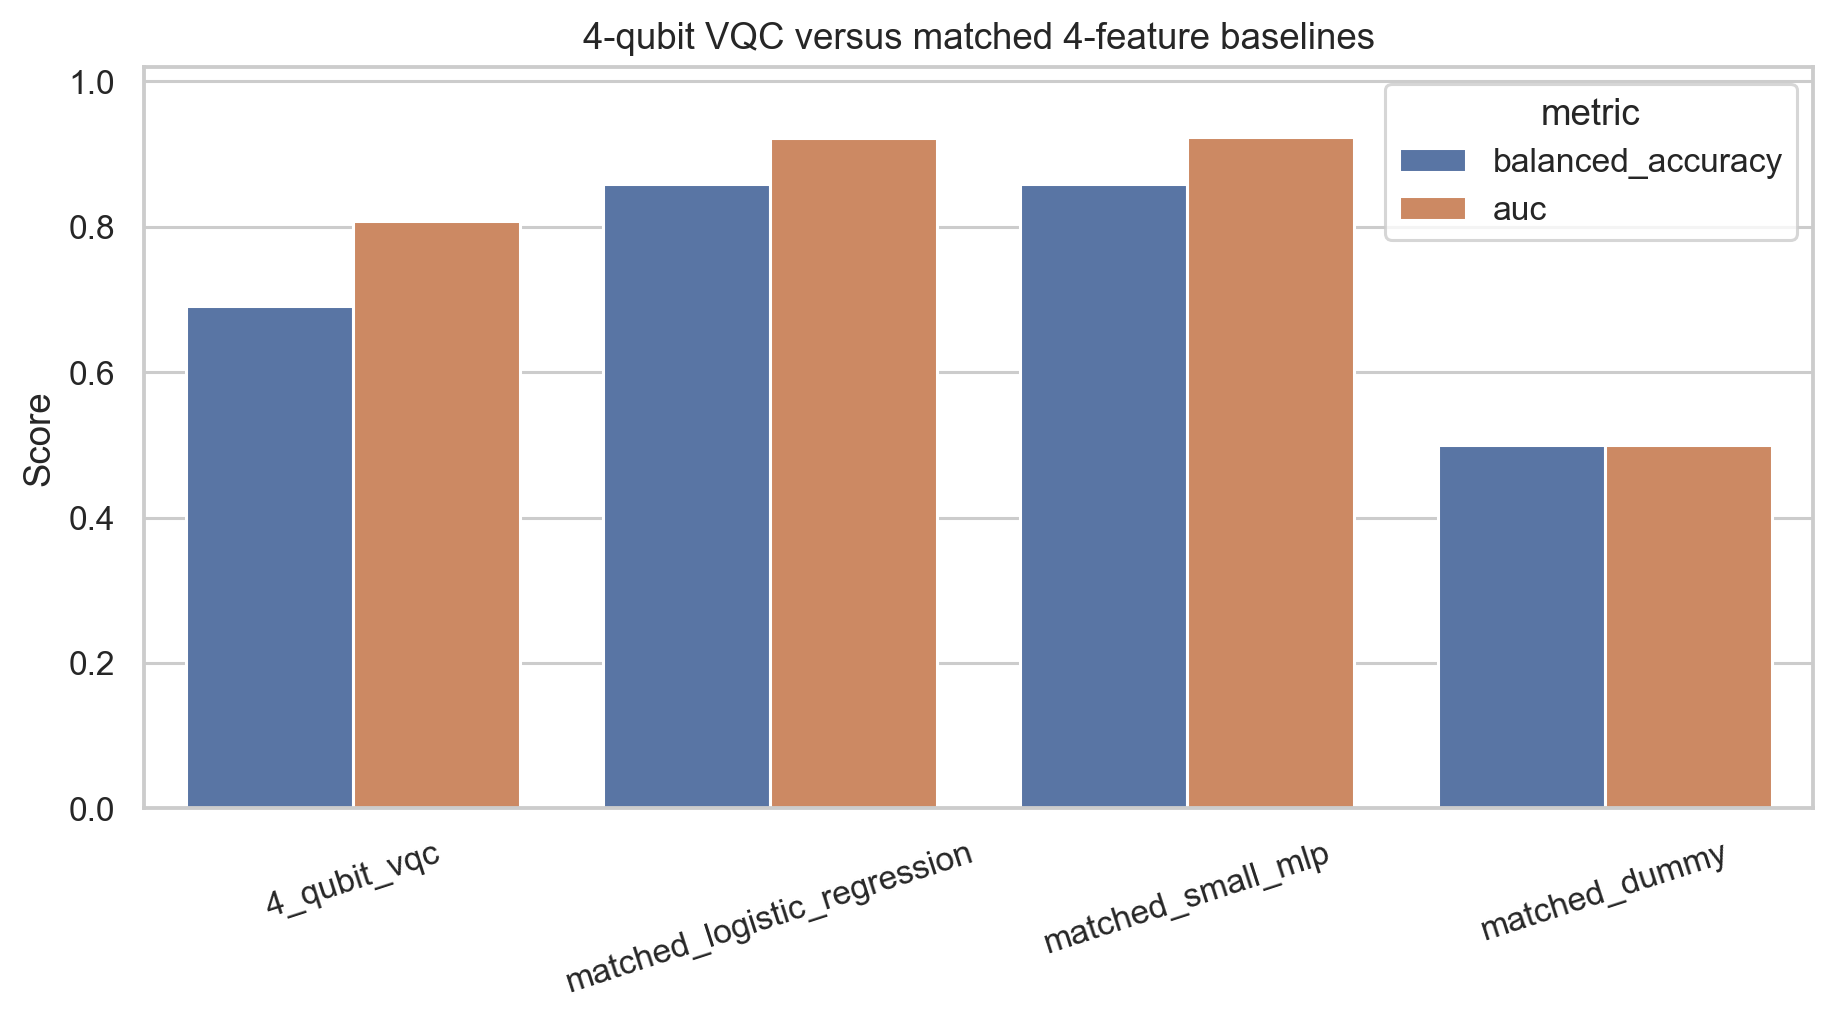

PosixPath('/Users/summermalik/Desktop/medical-msint/output/figures/quantum_vs_matched_classical.png')

In [14]:
vqc_positive_probabilities = np.asarray(vqc_predict_proba(Xq_test, vqc_parameters), dtype=float)
vqc_predictions = (vqc_positive_probabilities >= 0.5).astype(int)
vqc_probability_matrix = np.column_stack([1 - vqc_positive_probabilities, vqc_positive_probabilities])
vqc_metrics = metric_bundle(yq_test_bin, vqc_predictions, vqc_probability_matrix)

matched_models = {
    "matched_logistic_regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "matched_small_mlp": MLPClassifier(
        hidden_layer_sizes=(8,), max_iter=400, random_state=SEED
    ),
    "matched_dummy": DummyClassifier(strategy="prior", random_state=SEED),
}

quantum_summary_rows = [{
    "dataset": QUANTUM_DATASET_NAME,
    "model": "4_qubit_vqc",
    "features": K_QUBITS,
    "train_n": len(Xq_train),
    "test_n": len(Xq_test),
    **vqc_metrics,
}]
matched_predictions = {}
matched_probabilities = {}
for model_name, model in matched_models.items():
    model.fit(Xq_train, yq_train_bin)
    predictions = model.predict(Xq_test)
    probabilities = probability_matrix(model, Xq_test)
    matched_predictions[model_name] = predictions
    matched_probabilities[model_name] = probabilities
    quantum_summary_rows.append({
        "dataset": QUANTUM_DATASET_NAME,
        "model": model_name,
        "features": K_QUBITS,
        "train_n": len(Xq_train),
        "test_n": len(Xq_test),
        **metric_bundle(yq_test_bin, predictions, probabilities),
    })

quantum_summary_df = pd.DataFrame(quantum_summary_rows)
save_table(quantum_summary_df, "quantum_summary.csv")
display(quantum_summary_df)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
long_summary = quantum_summary_df.melt(
    id_vars="model", value_vars=["balanced_accuracy", "auc"],
    var_name="metric", value_name="score",
)
sns.barplot(data=long_summary, x="model", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1.02)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("4-qubit VQC versus matched 4-feature baselines")
ax.tick_params(axis="x", rotation=18)
fig.tight_layout()
save_figure("quantum_vs_matched_classical.png", fig)

## Quantum diagnostic preservation audit

This audit compares the probability-response magnitude of the VQC and matched logistic model with the full-feature logistic reference on the same test examples. Differences can arise from both the four-feature representation and the model family; this experiment does not uniquely attribute them to “quantumness.”

,dataset,probe,reference_probability_shift,reference_flip_rate,vqc_probability_shift,vqc_flip_rate,vqc_response_ratio,vqc_response_distortion,vqc_preservation_score,matched_logistic_probability_shift,matched_logistic_flip_rate,matched_logistic_response_ratio,matched_logistic_response_distortion,matched_logistic_preservation_score
0,pneumoniamnist,center_occlusion,0.159250,0.158333,0.038425,0.133333,0.241287,0.120825,0.388769,0.014158,0.008333,0.088907,0.145091,0.163295
1,pneumoniamnist,texture_weakening,0.075317,0.100000,0.007544,0.033333,0.100159,0.067773,0.182081,0.024155,0.008333,0.320712,0.051162,0.485665
2,pneumoniamnist,boundary_weakening,0.039751,0.058333,0.006042,0.033333,0.151996,0.033709,0.263883,0.019012,0.008333,0.478271,0.020739,0.647068
3,pneumoniamnist,contrast_attenuation,0.269895,0.300000,0.054037,0.216667,0.200217,0.215857,0.333634,0.314494,0.450000,1.165245,0.044599,0.923683
4,pneumoniamnist,gaussian_like_noise,0.086098,0.100000,0.005386,0.033333,0.062560,0.080711,0.117754,0.015115,0.008333,0.175558,0.070983,0.298681
5,pneumoniamnist,off_center_occlusion,0.026686,0.025000,0.070452,0.283333,2.640025,0.043766,0.549447,0.173123,0.158333,6.487359,0.146437,0.267117


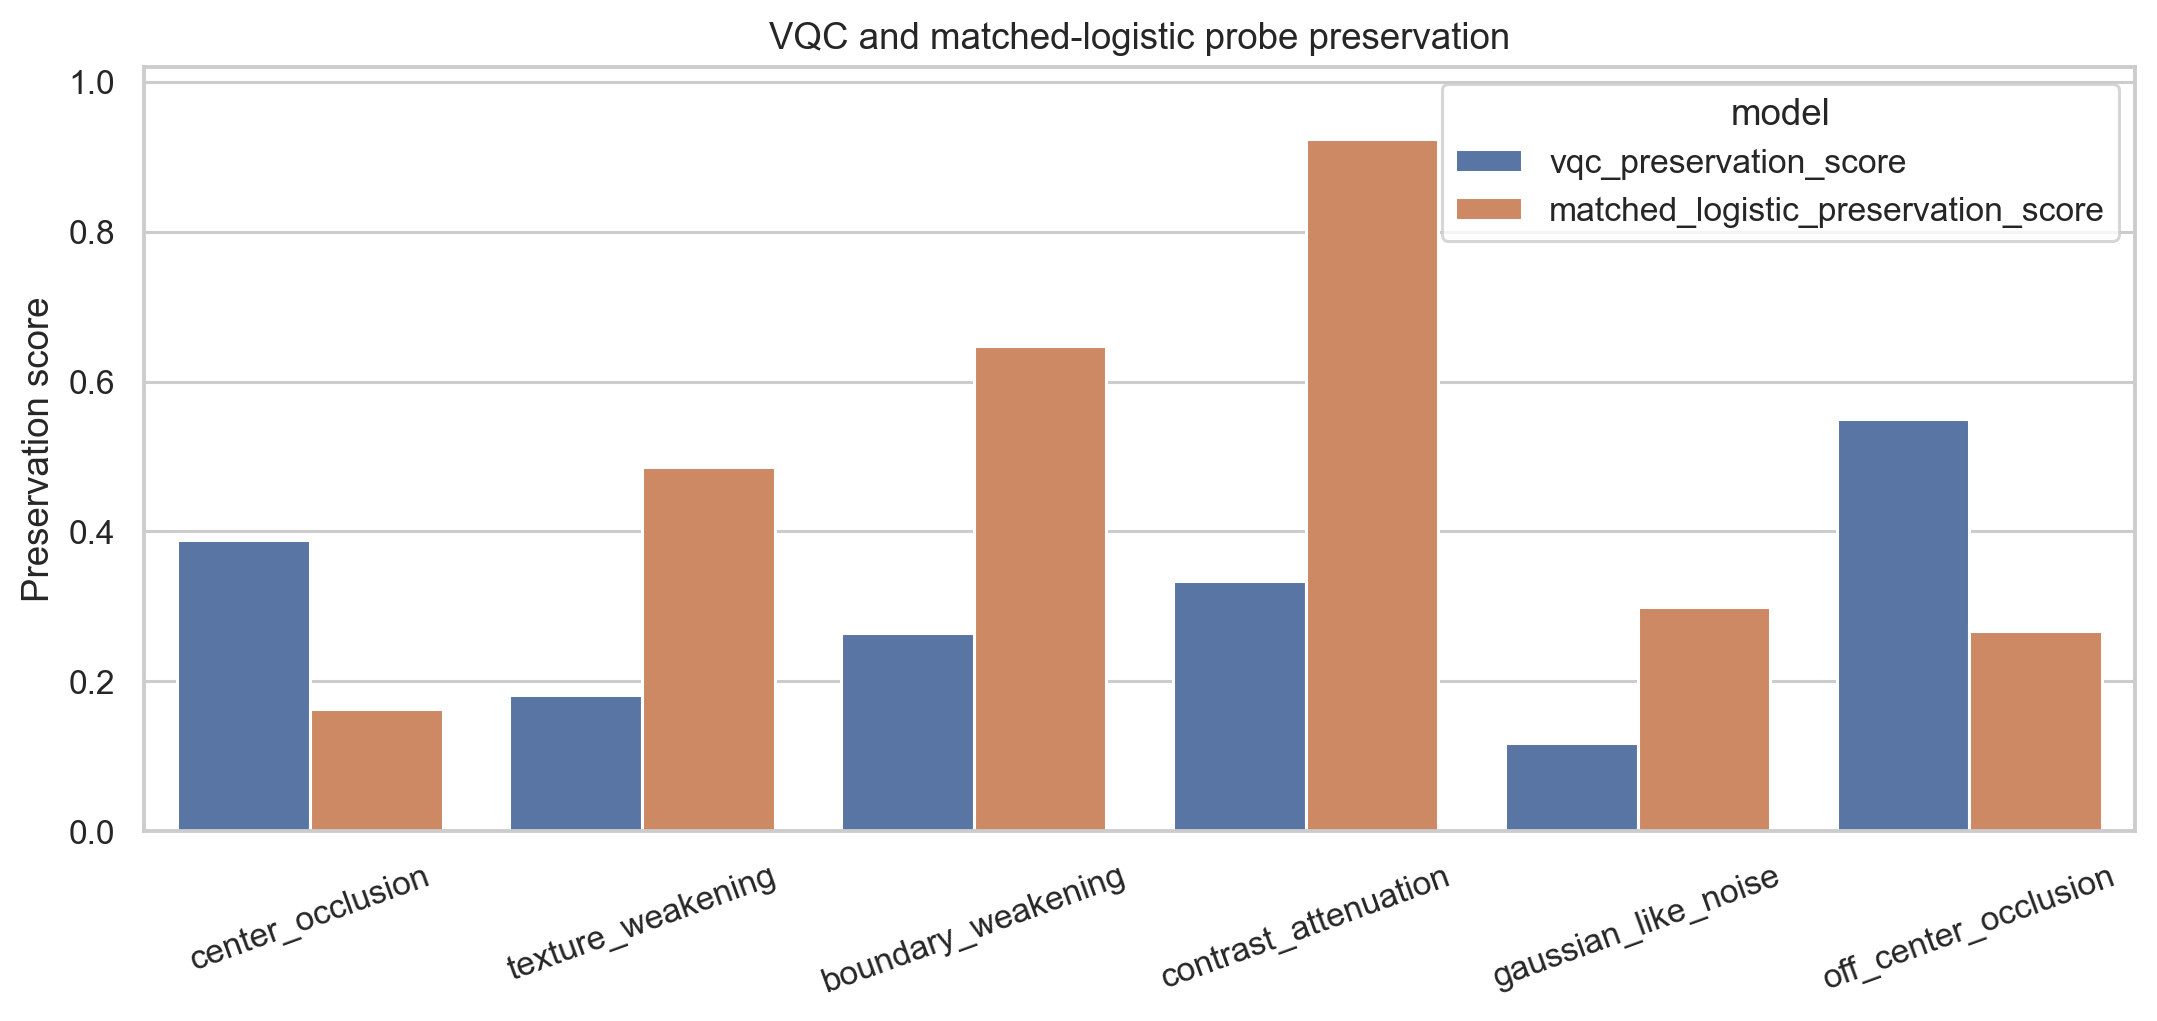

PosixPath('/Users/summermalik/Desktop/medical-msint/output/figures/vqc_probe_preservation.png')

In [15]:
reference_model_q = qdata["reference_model"]
x_reference_test = qdata["X_test_flat"][q_test_idx]
reference_original_prob = probability_matrix(reference_model_q, x_reference_test)
reference_original_pred = reference_model_q.predict(x_reference_test)

matched_logistic = matched_models["matched_logistic_regression"]
matched_original_prob = matched_probabilities["matched_logistic_regression"]
matched_original_pred = matched_predictions["matched_logistic_regression"]

quantum_preservation_rows = []
for probe_name, probe_flat_all in qdata["probe_flat_sets"].items():
    probe_flat = probe_flat_all[q_test_idx]
    reference_probe_prob = probability_matrix(reference_model_q, probe_flat)
    reference_probe_pred = reference_model_q.predict(probe_flat)
    reference_shift = probability_shift(reference_original_prob, reference_probe_prob)
    reference_flip = flip_rate(reference_original_pred, reference_probe_pred)

    probe_q = transform_to_quantum_features(probe_flat)
    vqc_probe_positive = np.asarray(vqc_predict_proba(probe_q, vqc_parameters), dtype=float)
    vqc_probe_prob = np.column_stack([1 - vqc_probe_positive, vqc_probe_positive])
    vqc_probe_pred = (vqc_probe_positive >= 0.5).astype(int)
    vqc_shift = probability_shift(vqc_probability_matrix, vqc_probe_prob)
    vqc_flip = flip_rate(vqc_predictions, vqc_probe_pred)

    matched_probe_prob = probability_matrix(matched_logistic, probe_q)
    matched_probe_pred = matched_logistic.predict(probe_q)
    matched_shift = probability_shift(matched_original_prob, matched_probe_prob)
    matched_flip = flip_rate(matched_original_pred, matched_probe_pred)

    quantum_preservation_rows.append({
        "dataset": QUANTUM_DATASET_NAME,
        "probe": probe_name,
        "reference_probability_shift": reference_shift,
        "reference_flip_rate": reference_flip,
        "vqc_probability_shift": vqc_shift,
        "vqc_flip_rate": vqc_flip,
        "vqc_response_ratio": response_ratio(reference_shift, vqc_shift),
        "vqc_response_distortion": abs(vqc_shift - reference_shift),
        "vqc_preservation_score": preservation_score(reference_shift, vqc_shift),
        "matched_logistic_probability_shift": matched_shift,
        "matched_logistic_flip_rate": matched_flip,
        "matched_logistic_response_ratio": response_ratio(reference_shift, matched_shift),
        "matched_logistic_response_distortion": abs(matched_shift - reference_shift),
        "matched_logistic_preservation_score": preservation_score(reference_shift, matched_shift),
    })

quantum_preservation_df = pd.DataFrame(quantum_preservation_rows)
save_table(quantum_preservation_df, "quantum_preservation_results.csv")
display(quantum_preservation_df)

plot_quantum_preservation = quantum_preservation_df.melt(
    id_vars="probe",
    value_vars=["vqc_preservation_score", "matched_logistic_preservation_score"],
    var_name="model", value_name="preservation_score",
)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(data=plot_quantum_preservation, x="probe", y="preservation_score", hue="model", ax=ax)
ax.set_ylim(0, 1.02)
ax.set_xlabel("")
ax.set_ylabel("Preservation score")
ax.set_title("VQC and matched-logistic probe preservation")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
save_figure("vqc_probe_preservation.png", fig)

## Patch-sweep occlusion sensitivity

A moving occlusion patch provides a spatial stress test. Each heatmap cell is the mean probability shift caused by occluding that location. The difference panel is **compressed minus reference**: positive values indicate amplified compressed-model sensitivity and negative values indicate dampened sensitivity.

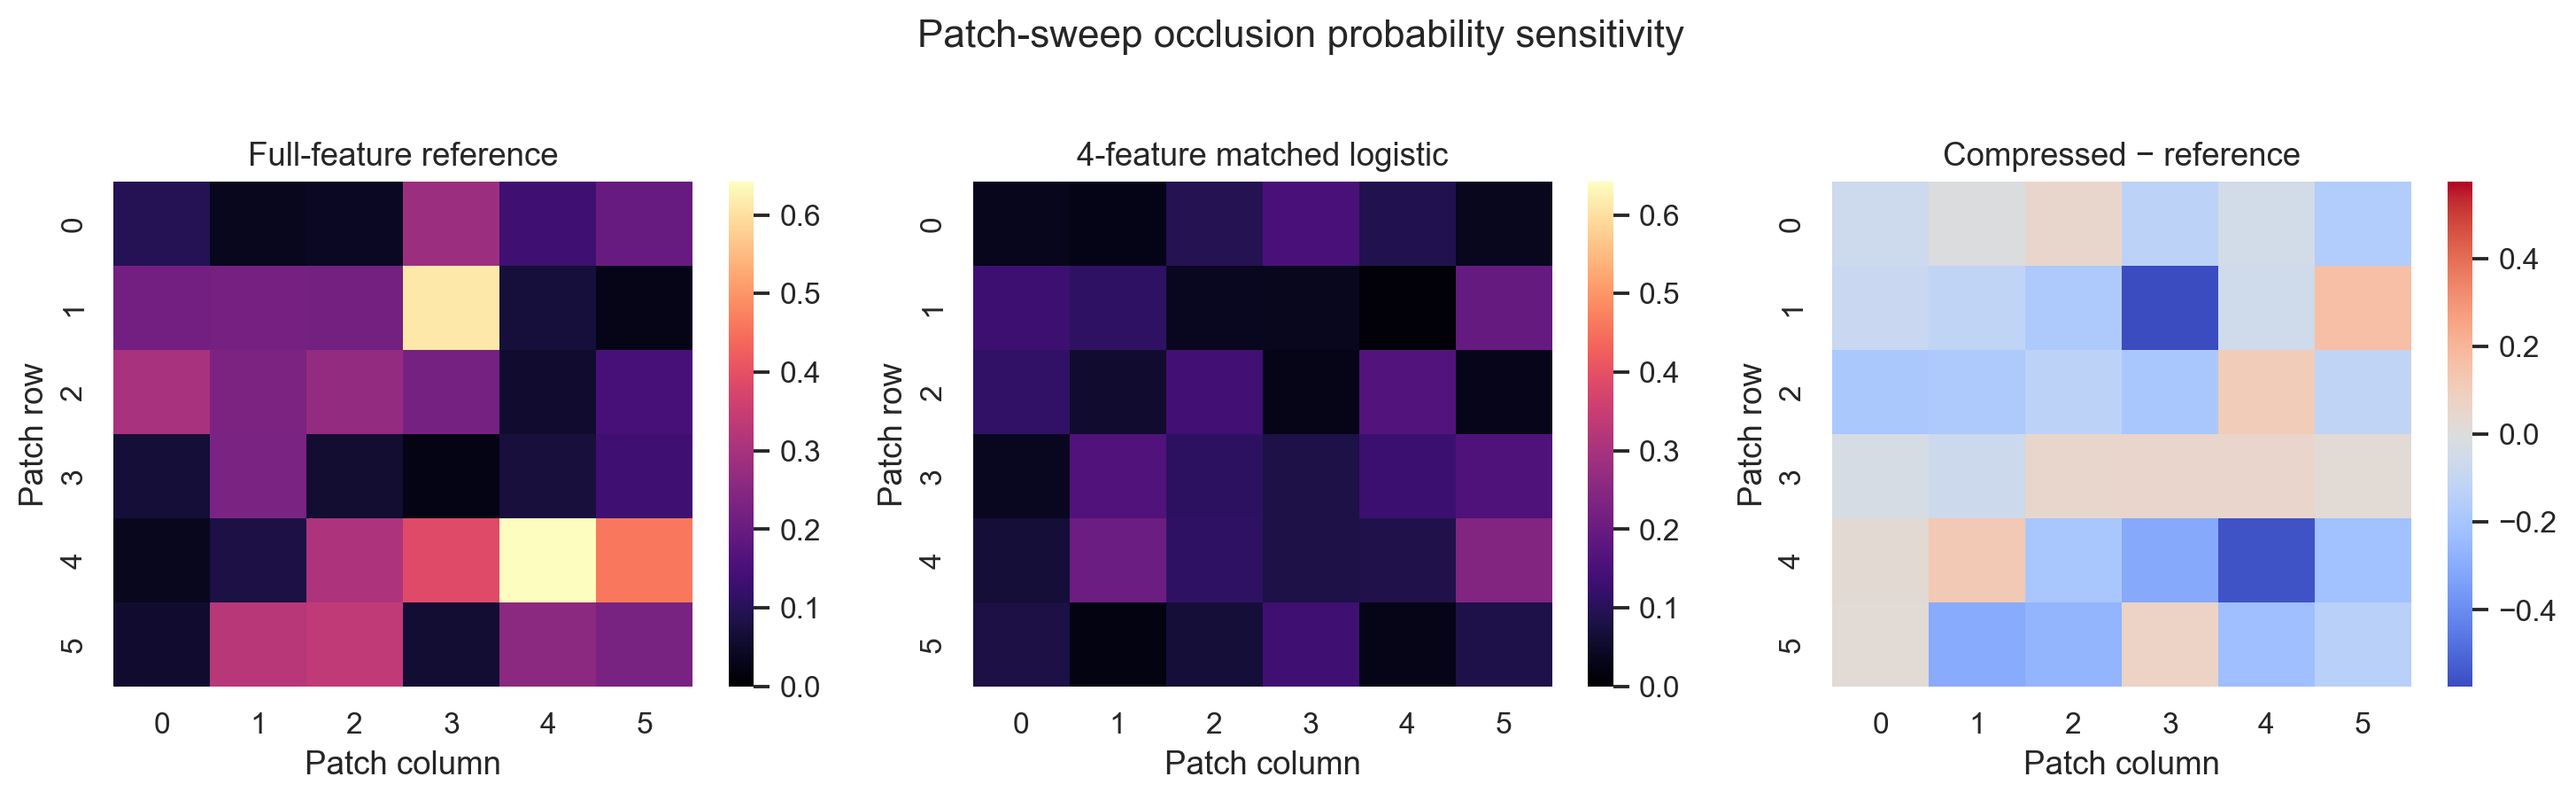

PosixPath('/Users/summermalik/Desktop/medical-msint/output/results/patch_sweep_occlusion_results.csv')

In [16]:
patch_size = 6
sweep_positions = list(range(0, 28 - patch_size + 1, 4))
reference_sensitivity = np.zeros((len(sweep_positions), len(sweep_positions)))
compressed_sensitivity = np.zeros_like(reference_sensitivity)
sweep_images = qdata["X_test"][q_test_idx]

for row, top in enumerate(sweep_positions):
    for col, left in enumerate(sweep_positions):
        occluded = patch_occlusion(sweep_images, top, left, patch_size)
        occluded_flat = flatten_images(occluded)
        ref_probe_prob = probability_matrix(reference_model_q, occluded_flat)
        reference_sensitivity[row, col] = probability_shift(reference_original_prob, ref_probe_prob)

        occluded_q = transform_to_quantum_features(occluded_flat)
        compressed_probe_prob = probability_matrix(matched_logistic, occluded_q)
        compressed_sensitivity[row, col] = probability_shift(
            matched_original_prob, compressed_probe_prob
        )

sensitivity_difference = compressed_sensitivity - reference_sensitivity
common_max = max(reference_sensitivity.max(), compressed_sensitivity.max(), 1e-6)
difference_max = max(np.abs(sensitivity_difference).max(), 1e-6)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
sns.heatmap(reference_sensitivity, vmin=0, vmax=common_max, cmap="magma", ax=axes[0])
sns.heatmap(compressed_sensitivity, vmin=0, vmax=common_max, cmap="magma", ax=axes[1])
sns.heatmap(
    sensitivity_difference, vmin=-difference_max, vmax=difference_max,
    center=0, cmap="coolwarm", ax=axes[2]
)
axes[0].set_title("Full-feature reference")
axes[1].set_title("4-feature matched logistic")
axes[2].set_title("Compressed − reference")
for ax in axes:
    ax.set_xlabel("Patch column")
    ax.set_ylabel("Patch row")
fig.suptitle("Patch-sweep occlusion probability sensitivity", y=1.02)
fig.tight_layout()
save_figure("occlusion_sensitivity_reference_vs_compressed.png", fig)

patch_sweep_df = pd.DataFrame([
    {
        "row": row,
        "column": col,
        "top_pixel": top,
        "left_pixel": left,
        "reference_sensitivity": reference_sensitivity[row, col],
        "compressed_sensitivity": compressed_sensitivity[row, col],
        "difference_compressed_minus_reference": sensitivity_difference[row, col],
    }
    for row, top in enumerate(sweep_positions)
    for col, left in enumerate(sweep_positions)
])
save_table(patch_sweep_df, "patch_sweep_occlusion_results.csv")

## Negative controls

A single shuffled-label run is too unstable for a small test set. The matched 4-feature logistic model is therefore refit after 50 independent training-label permutations. The full distribution is compared with both VQC and matched-logistic performance. A high or overlapping null distribution is a reason to audit leakage, sample size, or split construction before making strong claims.

,metric,n_shuffles,mean,std,min,max,q95
0,accuracy,50,0.544167,0.160438,0.158333,0.833333,0.796250
1,balanced_accuracy,50,0.544167,0.160438,0.158333,0.833333,0.796250
2,macro_f1,50,0.538399,0.161789,0.155460,0.832589,0.795752
3,auc,50,0.555389,0.207012,0.097500,0.893056,0.863569


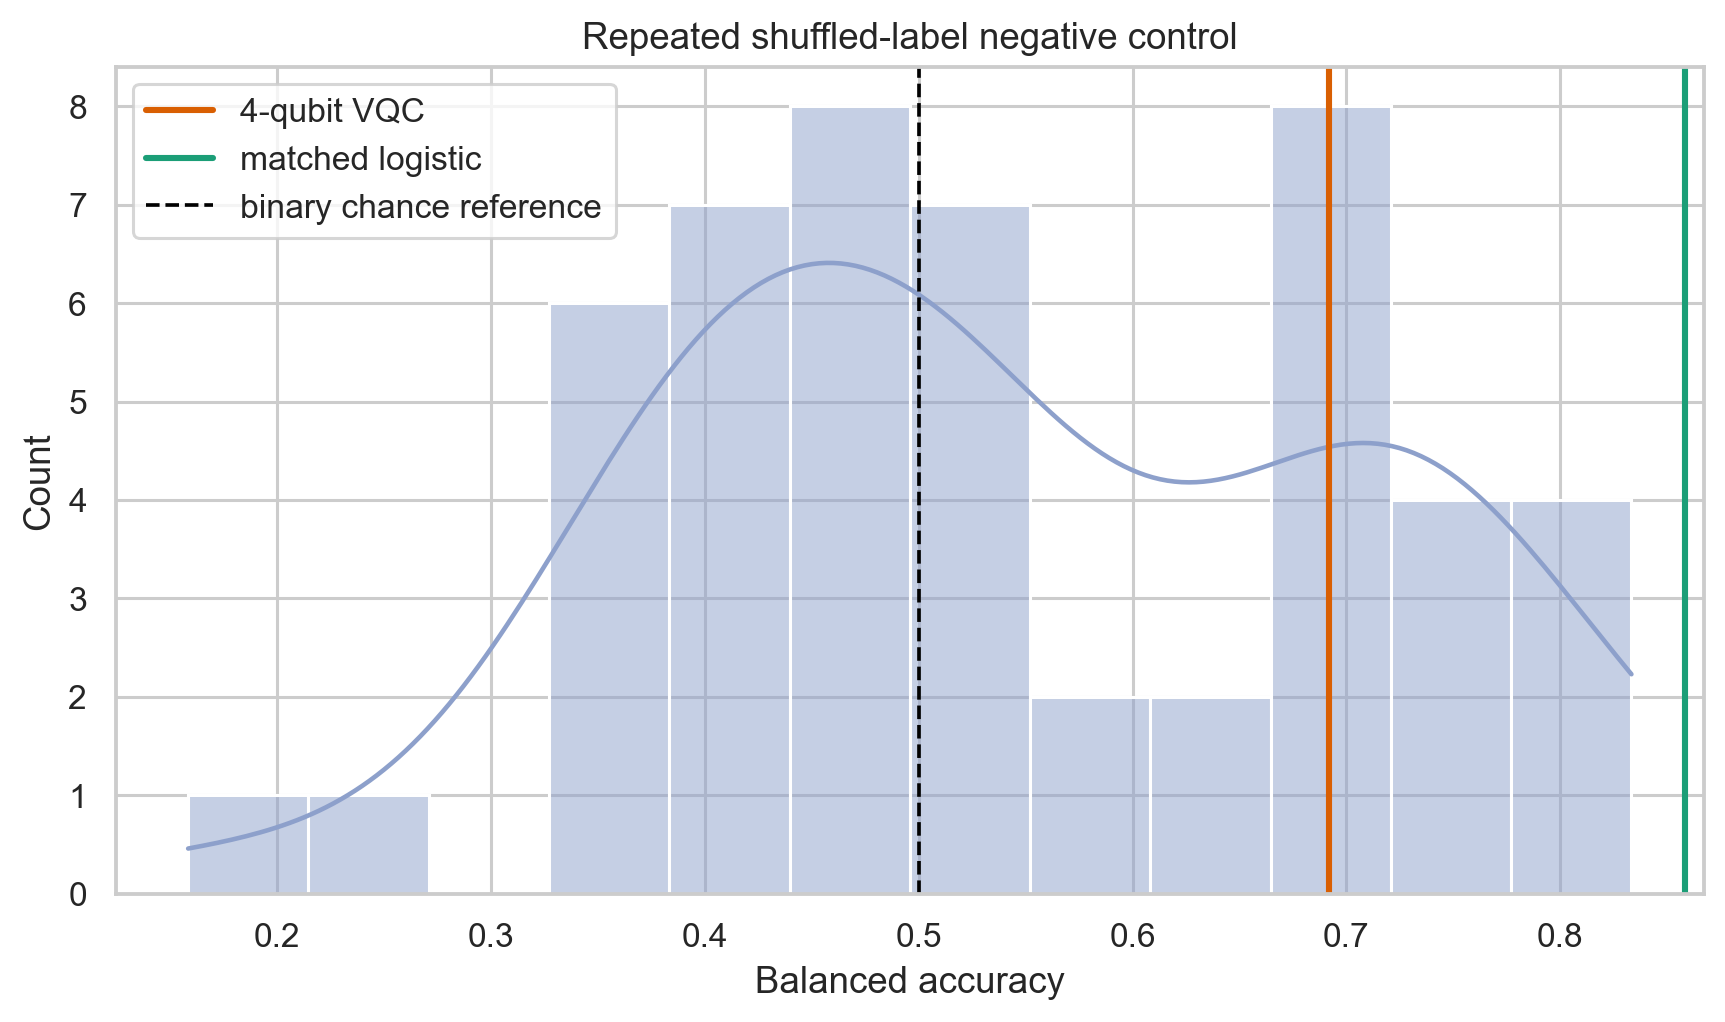

**⚠ Negative-control warning:** shuffled-label performance is unexpectedly high or overlaps the observed models. The control requires further audit before strong claims.

In [17]:
negative_control_rows = []
for repeat in range(N_SHUFFLES):
    shuffle_rng = np.random.default_rng(SEED + 1000 + repeat)
    shuffled_labels = shuffle_rng.permutation(yq_train_bin)
    negative_model = LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED + repeat
    )
    negative_model.fit(Xq_train, shuffled_labels)
    negative_predictions = negative_model.predict(Xq_test)
    negative_probabilities = probability_matrix(negative_model, Xq_test)
    negative_control_rows.append({
        "repeat": repeat,
        **metric_bundle(yq_test_bin, negative_predictions, negative_probabilities),
    })

negative_control_iterations_df = pd.DataFrame(negative_control_rows)
save_table(negative_control_iterations_df, "negative_control_iterations.csv")

negative_summary_rows = []
for metric in ["accuracy", "balanced_accuracy", "macro_f1", "auc"]:
    values = negative_control_iterations_df[metric].dropna()
    negative_summary_rows.append({
        "metric": metric,
        "n_shuffles": len(values),
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "min": values.min(),
        "max": values.max(),
        "q95": values.quantile(0.95),
    })
negative_control_df = pd.DataFrame(negative_summary_rows)
save_table(negative_control_df, "negative_control_results.csv")
display(negative_control_df)

matched_balanced_accuracy = float(
    quantum_summary_df.loc[
        quantum_summary_df["model"] == "matched_logistic_regression", "balanced_accuracy"
    ].iloc[0]
)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.histplot(
    negative_control_iterations_df["balanced_accuracy"], bins=12, kde=True,
    color="#8da0cb", ax=ax,
)
ax.axvline(vqc_metrics["balanced_accuracy"], color="#d95f02", linewidth=2, label="4-qubit VQC")
ax.axvline(matched_balanced_accuracy, color="#1b9e77", linewidth=2, label="matched logistic")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="binary chance reference")
ax.set_xlabel("Balanced accuracy")
ax.set_title("Repeated shuffled-label negative control")
ax.legend()
fig.tight_layout()
save_figure("repeated_negative_control_histogram.png", fig)

null_q95 = float(
    negative_control_df.loc[
        negative_control_df["metric"] == "balanced_accuracy", "q95"
    ].iloc[0]
)
null_mean = float(
    negative_control_df.loc[
        negative_control_df["metric"] == "balanced_accuracy", "mean"
    ].iloc[0]
)
if (
    null_mean > 0.60
    or null_q95 > 0.65
    or max(vqc_metrics["balanced_accuracy"], matched_balanced_accuracy) <= null_q95
):
    display(Markdown(
        "**⚠ Negative-control warning:** shuffled-label performance is unexpectedly high "
        "or overlaps the observed models. The control requires further audit before strong claims."
    ))
else:
    display(Markdown(
        "**Negative-control check:** the repeated shuffled-label distribution remains near the "
        "binary chance reference and below at least one observed matched model."
    ))

## Statistical reliability checks

Nonparametric bootstrap intervals summarize test-set uncertainty for balanced accuracy and AUC. Resampling is performed on the paired test predictions, so these intervals reflect sampling variability of this working test subset; they do not capture dataset shift, hyperparameter uncertainty, quantum hardware noise, or variation across VQC training seeds.

In [18]:
def bootstrap_metric_interval(labels, predictions, positive_probabilities, metric, n_boot=N_BOOTSTRAPS):
    rng = np.random.default_rng(SEED + 5000)
    values = []
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    positive_probabilities = np.asarray(positive_probabilities)
    for _ in range(n_boot):
        indices = rng.integers(0, len(labels), size=len(labels))
        sampled_labels = labels[indices]
        if len(np.unique(sampled_labels)) < 2:
            continue
        if metric == "balanced_accuracy":
            value = balanced_accuracy_score(sampled_labels, predictions[indices])
        elif metric == "auc":
            value = roc_auc_score(sampled_labels, positive_probabilities[indices])
        else:
            raise ValueError(metric)
        values.append(float(value))
    values = np.asarray(values)
    return float(np.mean(values)), float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975)), len(values)


reliability_models = {
    "4_qubit_vqc": (vqc_predictions, vqc_positive_probabilities),
    "matched_logistic_regression": (
        matched_predictions["matched_logistic_regression"],
        matched_probabilities["matched_logistic_regression"][:, 1],
    ),
    "matched_small_mlp": (
        matched_predictions["matched_small_mlp"],
        matched_probabilities["matched_small_mlp"][:, 1],
    ),
}
bootstrap_rows = []
for model_name, (predictions, probabilities) in reliability_models.items():
    for metric in ["balanced_accuracy", "auc"]:
        mean, lower, upper, valid = bootstrap_metric_interval(
            yq_test_bin, predictions, probabilities, metric
        )
        bootstrap_rows.append({
            "model": model_name,
            "metric": metric,
            "bootstrap_mean": mean,
            "ci_2.5_percent": lower,
            "ci_97.5_percent": upper,
            "valid_resamples": valid,
        })

bootstrap_confidence_intervals_df = pd.DataFrame(bootstrap_rows)
save_table(bootstrap_confidence_intervals_df, "bootstrap_confidence_intervals.csv")
display(bootstrap_confidence_intervals_df)

,model,metric,bootstrap_mean,ci_2.5_percent,ci_97.5_percent,valid_resamples
0,4_qubit_vqc,balanced_accuracy,0.695988,0.614569,0.768727,500
1,4_qubit_vqc,auc,0.808984,0.727364,0.880053,500
2,matched_logistic_regression,balanced_accuracy,0.860227,0.800618,0.913654,500
3,matched_logistic_regression,auc,0.924075,0.873436,0.964577,500
4,matched_small_mlp,balanced_accuracy,0.860227,0.800618,0.913654,500
5,matched_small_mlp,auc,0.924921,0.875100,0.965144,500


## Main findings

The next cell generates a run-specific summary rather than hard-coding a preferred outcome. Interpret effect sizes with the tables, plots, null distribution, and uncertainty intervals—not as a model leaderboard.

In [19]:
four_component_viability = viability_df[viability_df["components"] == K_QUBITS]
lowest_preservation = preservation_df.loc[
    preservation_df["diagnostic_information_preservation_score"].idxmin()
]
vqc_row = quantum_summary_df[quantum_summary_df["model"] == "4_qubit_vqc"].iloc[0]
matched_row = quantum_summary_df[
    quantum_summary_df["model"] == "matched_logistic_regression"
].iloc[0]

summary_lines = [
    "### Run-specific summary",
    "",
    f"- The audit completed across **{len(DATASET_NAMES)} datasets** and "
    f"**{len(COMPRESSION_LEVELS)} PCA dimensions**.",
    f"- At four components, mean logistic-regression balanced accuracy across datasets was "
    f"**{four_component_viability['balanced_accuracy'].mean():.3f}**, while mean probe-preservation "
    f"was **{four_component_viability['mean_preservation_score'].mean():.3f}**.",
    f"- The lowest observed preservation score was **{lowest_preservation['diagnostic_information_preservation_score']:.3f}** "
    f"for `{lowest_preservation['probe']}` on `{lowest_preservation['dataset']}` at "
    f"{int(lowest_preservation['components'])} components.",
    f"- The 4-qubit VQC achieved balanced accuracy **{vqc_row['balanced_accuracy']:.3f}** and AUC "
    f"**{vqc_row['auc']:.3f}**; matched logistic regression achieved **{matched_row['balanced_accuracy']:.3f}** "
    f"and **{matched_row['auc']:.3f}**, respectively.",
    "- The methodological conclusion does not depend on which matched model scores highest: "
    "qubit-limited results require representation auditing, matched compressed baselines, negative controls, and uncertainty.",
]
display(Markdown("\n".join(summary_lines)))

### Run-specific summary

- The audit completed across **3 datasets** and **5 PCA dimensions**.
- At four components, mean logistic-regression balanced accuracy across datasets was **0.691**, while mean probe-preservation was **0.422**.
- The lowest observed preservation score was **0.022** for `texture_weakening` on `pathmnist` at 4 components.
- The 4-qubit VQC achieved balanced accuracy **0.692** and AUC **0.807**; matched logistic regression achieved **0.858** and **0.922**, respectively.
- The methodological conclusion does not depend on which matched model scores highest: qubit-limited results require representation auditing, matched compressed baselines, negative controls, and uncertainty.

## What this proves and what it does not prove

**Supported by this notebook**

- Classification performance, PCA variance, and perturbation-response preservation can be measured separately under an explicit qubit-limited bottleneck.
- Matched compressed baselines can distinguish representation limitations from claims about a quantum model.
- Controlled probes can reveal dampened or amplified model sensitivity that aggregate accuracy may hide.

**Not supported by this notebook**

- It does not prove quantum advantage or superiority over classical learning.
- It does not diagnose disease, validate biomarkers, or establish clinical utility.
- It does not make perturbation probes clinical ground truth.
- It does not establish that the full-feature reference model uses medically correct evidence.
- It does not reproduce noise, calibration drift, sampling noise, or error mitigation on real quantum hardware.

The protected interpretation is: **qubit-limited compression can retain classification signal while changing evidence sensitivity; therefore quantum medical-imaging benchmarks should report preservation audits and matched compressed baselines alongside accuracy.**

## Limitations and future work

This is a small-sample, post-hoc audit of standardized 28×28 images. PCA is linear; the probes are synthetic; the reference model is not clinically validated; hyperparameters are intentionally light; and one VQC seed cannot characterize optimization instability. Balanced subsampling changes the operating distribution, and bootstrap intervals do not capture site or acquisition shift.

Future work should add clinically motivated annotations, radiologist-defined regions or features, nonlinear and learned compression, reconstruction-quality measures, repeated VQC seeds, nested validation, calibration metrics, full MedMNIST splits, external datasets, subgroup audits, and device-level encoding/noise studies. A particularly important extension is to decompose preservation loss into preprocessing, feature encoding, circuit noise, and classifier contributions.

## Proposed reporting checklist for quantum medical image classification under compression

- What dataset was used?
- What image representation entered the quantum circuit?
- What compression method was used?
- How many features or qubits were used?
- How much variance was retained?
- Were classical baselines trained on the same compressed representation?
- Were repeated seeds or confidence intervals reported?
- Were negative controls used?
- Was probe sensitivity or information preservation evaluated?
- Did the study distinguish representation failure from quantum model failure?

## References

1. Singh, G., Jin, H., & Merz, K. M. Jr. (2026). *Benchmarking MedMNIST dataset on real quantum hardware*. **Scientific Reports, 16**, 9017. https://doi.org/10.1038/s41598-026-35605-3
2. Yang, J. et al. (2023). *MedMNIST v2—A large-scale lightweight benchmark for 2D and 3D biomedical image classification*. **Scientific Data, 10**, 41. https://doi.org/10.1038/s41597-022-01721-8
3. Bergholm, V. et al. (2018). *PennyLane: Automatic differentiation of hybrid quantum-classical computations*. arXiv:1811.04968. https://arxiv.org/abs/1811.04968
4. Pedregosa, F. et al. (2011). *Scikit-learn: Machine learning in Python*. **Journal of Machine Learning Research, 12**, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

## Final contribution statement

This notebook contributes a compression-aware diagnostic information audit for quantum medical image classification. Building on quantum MedMNIST benchmarking, it evaluates not only whether a compressed quantum pipeline classifies images, but whether the image information used for classification survives the qubit-limited encoding process. The contribution is methodological: a reporting and evaluation framework for distinguishing quantum model performance from representation damage.

## SCCUR abstract draft

**Diagnostic information preservation in qubit-limited quantum medical image classification**

Quantum medical-image classifiers must compress high-dimensional images before qubit encoding, but benchmark accuracy alone cannot show whether decision-relevant image information survives that bottleneck. We present a compression-aware diagnostic information audit across [N_DATASETS] MedMNIST datasets. Images are compressed to [PCA_LEVELS] PCA dimensions and evaluated with matched classical baselines, explained variance, balanced accuracy, macro F1, AUC, and controlled perturbation probes. A preservation score compares compressed-model and full-feature-reference probability responses to occlusion, texture, boundary, contrast, and noise changes. We then evaluate a 4-qubit variational quantum classifier against logistic regression, a small MLP, dummy prediction, repeated shuffled-label controls, and bootstrap confidence intervals on the same four features. At four components, mean balanced accuracy was [BAL_ACC], while mean preservation was [PRESERVATION]; the largest response distortion occurred for [PROBE/DATASET]. The VQC achieved [VQC_METRICS] versus [MATCHED_METRICS] for matched logistic regression. These results do not establish quantum advantage or clinical validity. They show why quantum medical-imaging studies should report representation preservation, matched compressed baselines, negative controls, and uncertainty alongside accuracy.

In [20]:
required_tables = [
    "dataset_overview.csv",
    "classical_compression_results.csv",
    "variance_retention_results.csv",
    "preservation_results.csv",
    "most_damaged_probe_results.csv",
    "compression_viability_summary.csv",
    "quantum_summary.csv",
    "quantum_preservation_results.csv",
    "negative_control_results.csv",
    "bootstrap_confidence_intervals.csv",
]
required_figures = [
    "dataset_examples.png",
    "perturbation_probe_examples.png",
    "pca_variance_retention_by_dataset.png",
    "compression_accuracy_by_dataset.png",
    "preservation_heatmap_by_dataset.png",
    "variance_vs_preservation_scatter.png",
    "most_damaged_probe_by_dataset.png",
    "quantum_vs_matched_classical.png",
    "repeated_negative_control_histogram.png",
    "vqc_probe_preservation.png",
    "occlusion_sensitivity_reference_vs_compressed.png",
]
missing = [
    str(path)
    for path in [
        *[RESULTS_DIR / name for name in required_tables],
        *[FIGURES_DIR / name for name in required_figures],
    ]
    if not path.exists()
]
if missing:
    raise FileNotFoundError("Missing expected artifacts: " + ", ".join(missing))

manifest = {
    "status": "complete",
    "datasets": DATASET_NAMES,
    "compression_levels": COMPRESSION_LEVELS,
    "quantum_dataset": QUANTUM_DATASET_NAME,
    "tables": sorted(path.name for path in RESULTS_DIR.glob("*.csv")),
    "figures": sorted(path.name for path in FIGURES_DIR.glob("*.png")),
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
(LOGS_DIR / "runtime_configuration.json").write_text(json.dumps({
    "seed": SEED,
    "max_train": MAX_TRAIN,
    "max_test": MAX_TEST,
    "quantum_train_n": len(Xq_train),
    "quantum_test_n": len(Xq_test),
    "vqc_epochs": VQC_EPOCHS,
    "negative_control_repeats": N_SHUFFLES,
    "bootstrap_resamples": N_BOOTSTRAPS,
}, indent=2))

print(f"Verified {len(required_tables)} required tables and {len(required_figures)} required figures.")
print("Notebook completed successfully.")

Verified 10 required tables and 11 required figures.
Notebook completed successfully.
